# AgriPulse — Food Price Forecasting

**Bei Smart / AgriPulse Capstone — Moringa School Data Science**

This notebook documents the development of the forecasting layer, from a first
single-series baseline through to the multi-model production pipeline.

It is written as a record of how the work actually unfolded. Several approaches
were tried and abandoned; those are kept in place because the reasons they failed
shaped the final design.

**Contents**

1. Setup and data
2. A first baseline — SARIMA on one series
3. Prophet as a comparison
4. Trying deep learning — 1D CNN
5. Scaling to many markets
6. LSTM — testing the recurrent approach
7. Data quality problems found along the way
8. Adding external drivers — rainfall, fuel, geopolitical risk
9. Production pipeline and regional coverage
10. A second opinion — SARIMA at market level
11. Time-series foundation models — Chronos
12. Per-series model selection
13. Ensembling — an alternative to selection
14. Price anomaly detection
15. Market volatility
16. Regional price differences
17. Production artifacts

## 1. Setup and data

The forecasting dataset combines WFP monthly market prices with two supplementary
sources added later in the project, plus ERA5 rainfall matched to each region and
month. Prices are normalised to KES per kilogram so that series recorded in
90 kg bags, 50 kg sacks and litres can be compared.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, LSTM)
from tensorflow.keras.callbacks import EarlyStopping

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

In [3]:
DATA = r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned'

df = pd.read_csv(f'{DATA}\\bei_smart_forecasting.csv', parse_dates=['date'])

print(f"{len(df):,} rows | {df['date'].min():%b %Y} to {df['date'].max():%b %Y}")
print(f"{df['commodity'].nunique()} commodities across {df['market'].nunique()} markets")

26,228 rows | Jan 2006 to Aug 2026
47 commodities across 225 markets


### Choosing a starting series

Rather than modelling everything at once, we start with a single well-covered
series and get the method right before scaling. Maize is Kenya's staple crop and
the Nairobi wholesale series is the longest continuous record in the dataset.

189 monthly observations, Jan 2006 to Mar 2022


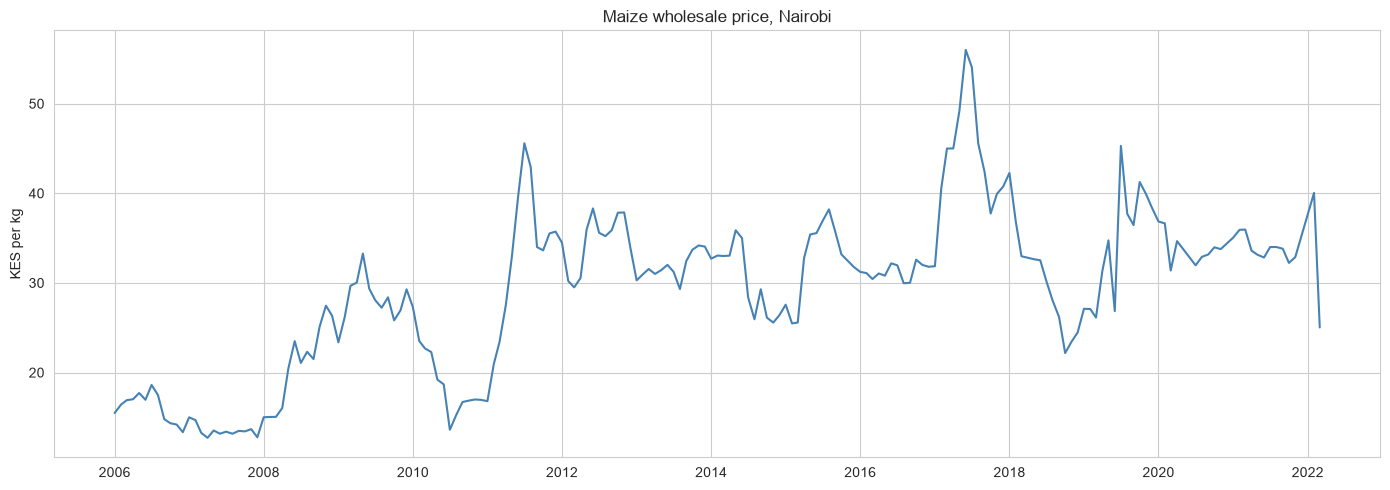

In [4]:
maize = (df[(df['commodity'] == 'Maize') &
            (df['market'] == 'Nairobi') &
            (df['pricetype'] == 'Wholesale')]
         .sort_values('date')
         .set_index('date')['price_per_kg']
         .resample('MS').mean()
         .dropna())

print(f'{len(maize)} monthly observations, {maize.index.min():%b %Y} to {maize.index.max():%b %Y}')

plt.plot(maize, color='steelblue')
plt.title('Maize wholesale price, Nairobi')
plt.ylabel('KES per kg')
plt.tight_layout()
plt.show()

The series shows a clear upward trend from around KES 15/kg in 2006 to the low
thirties by 2022, with two pronounced spikes — 2011 and 2017 — that correspond to
drought years. There is visible annual structure but it sits underneath a lot of
short-term noise.

Two things follow from this. The trend means the series is unlikely to be
stationary, so differencing will be needed. The repeating annual pattern means a
seasonal term is worth including.

## 2. A first baseline — SARIMA

SARIMA is the conventional starting point for monthly commodity prices. It models
the series as a function of its own recent values plus a seasonal lag, which
matches how food prices behave: this month resembles last month, and this March
resembles last March.

We hold out the final twelve months for evaluation and fit on everything before.

In [5]:
adf_stat, adf_p, *_ = adfuller(maize.dropna())
diff_stat, diff_p, *_ = adfuller(maize.diff().dropna())

print(f'ADF on levels        : p = {adf_p:.4f}')
print(f'ADF after differencing: p = {diff_p:.4f}')

ADF on levels        : p = 0.0614
ADF after differencing: p = 0.0000


The level series returns p = 0.06 — borderline, and not enough to reject
non-stationarity at the 5% level. After first differencing p falls to essentially
zero. That settles `d = 1`.

A seasonal decomposition confirms the annual cycle is real rather than an artefact
of the trend.

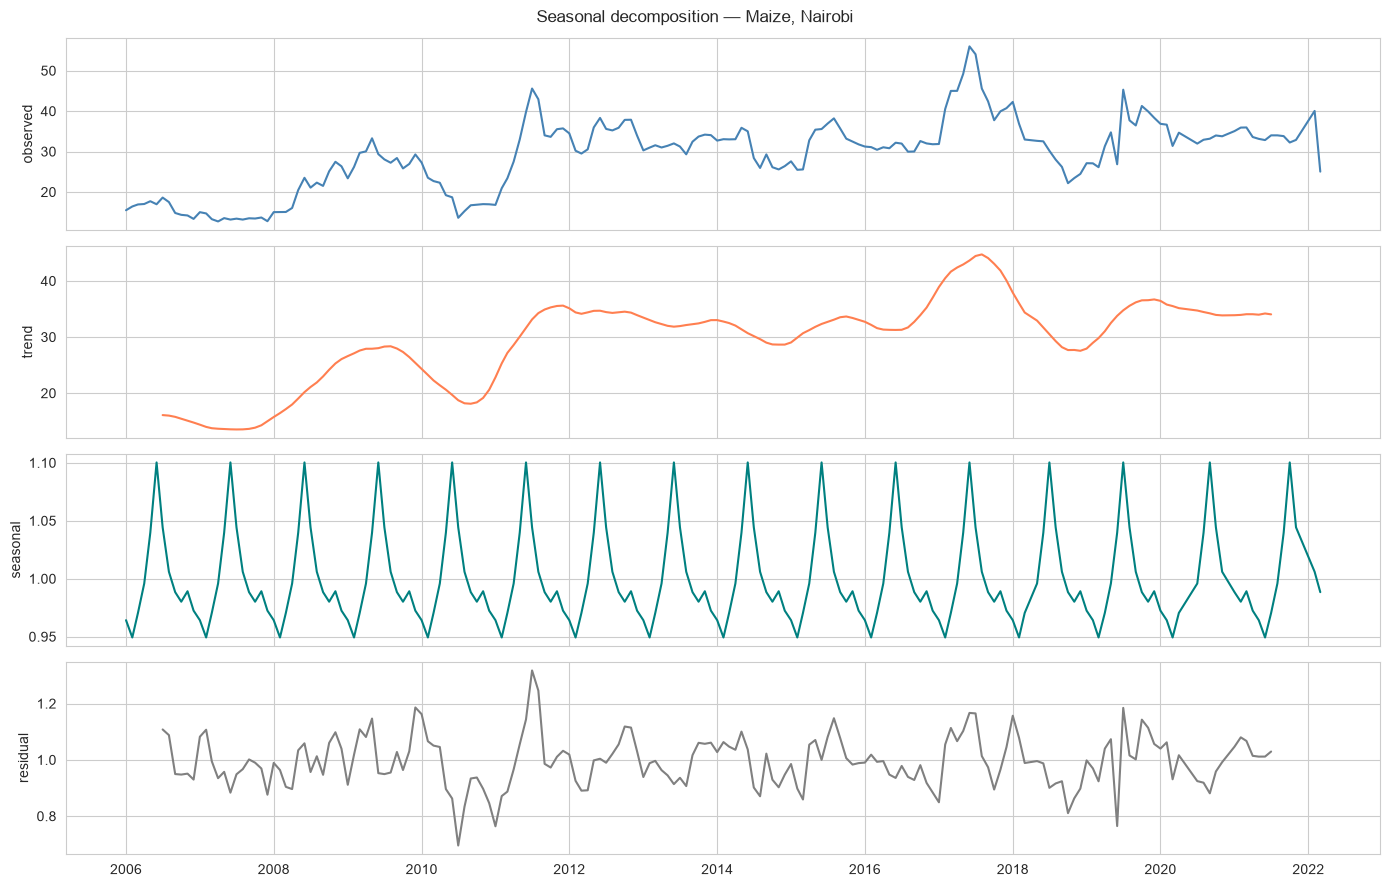

In [6]:
decomp = seasonal_decompose(maize, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(maize, color='steelblue');        axes[0].set_ylabel('observed')
axes[1].plot(decomp.trend, color='coral');     axes[1].set_ylabel('trend')
axes[2].plot(decomp.seasonal, color='teal');   axes[2].set_ylabel('seasonal')
axes[3].plot(decomp.resid, color='grey');      axes[3].set_ylabel('residual')
fig.suptitle('Seasonal decomposition — Maize, Nairobi')
plt.tight_layout()
plt.show()

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


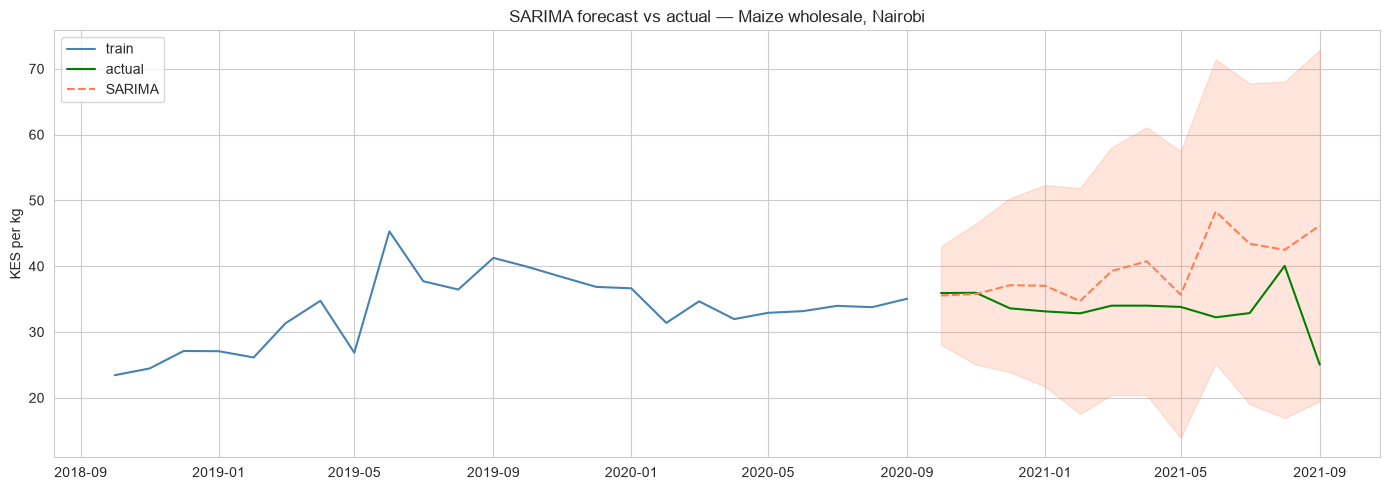

MAE  6.16 KES/kg
MAPE 20.23%


In [7]:
train_values = maize.values[:-12].astype(float)
test_values  = maize.values[-12:].astype(float)

train_idx = pd.date_range(start=maize.index[0], periods=len(train_values), freq='MS')
test_idx  = pd.date_range(start=train_idx[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

train_clean = pd.Series(train_values, index=train_idx)
test_clean  = pd.Series(test_values,  index=test_idx)

fit_sarima = SARIMAX(train_clean,
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 0, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)

forecast = fit_sarima.get_forecast(steps=12)
pred_sarima = forecast.predicted_mean
ci = forecast.conf_int()

plt.plot(train_clean[-24:], label='train', color='steelblue')
plt.plot(test_clean, label='actual', color='green')
plt.plot(pred_sarima, label='SARIMA', color='coral', linestyle='--')
plt.fill_between(pred_sarima.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.2, color='coral')
plt.title('SARIMA forecast vs actual — Maize wholesale, Nairobi')
plt.ylabel('KES per kg')
plt.legend()
plt.tight_layout()
plt.show()

mape_sarima = np.mean(np.abs((test_clean.values - pred_sarima.values) / test_clean.values)) * 100
print(f'MAE  {mean_absolute_error(test_clean.values, pred_sarima.values):.2f} KES/kg')
print(f'MAPE {mape_sarima:.2f}%')

**SARIMA baseline: 20.2% MAPE, MAE 6.16 KES/kg.**

The model holds the right price level but the confidence band is very wide — by
month twelve it spans roughly KES 20 to 70, which is too broad to act on. It also
smooths straight through the sharp movements in the holdout period.

That is expected behaviour for a univariate model, but it sets a low bar. Worth
seeing whether something else does better.

## 3. Prophet

Prophet takes a different approach: rather than modelling autocorrelation, it
decomposes the series into trend, seasonality and holiday effects, and detects
changepoints where the trend shifts. For a series with drought-driven regime
changes, automatic changepoint detection is potentially a good fit.

09:31:59 - cmdstanpy - INFO - Chain [1] start processing
09:32:00 - cmdstanpy - INFO - Chain [1] done processing


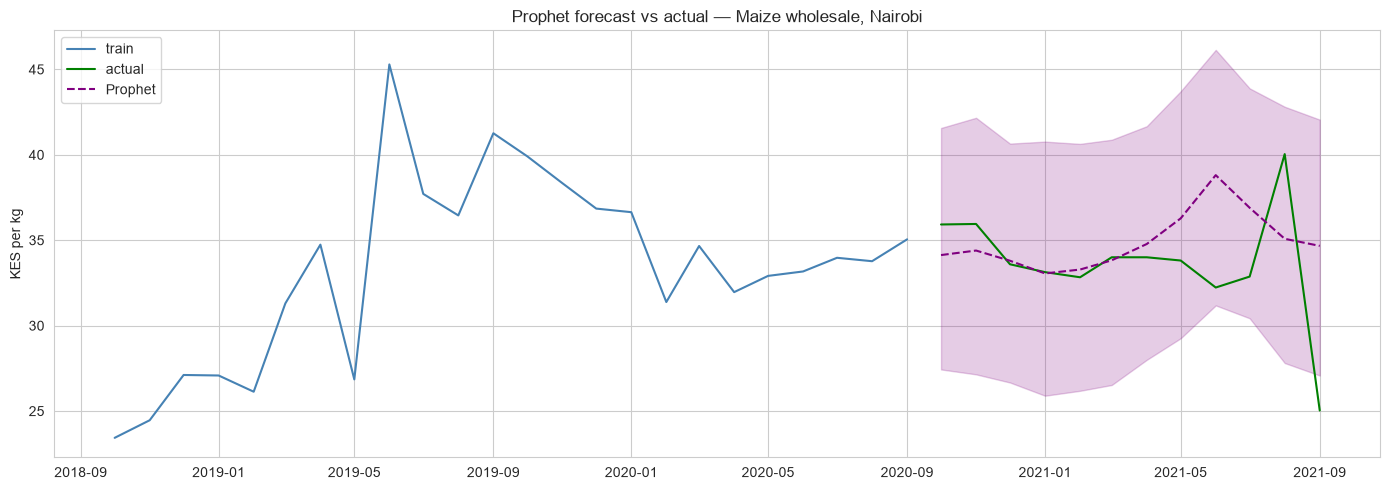

MAE  2.73 KES/kg
MAPE 8.77%


In [8]:
prophet_df = pd.DataFrame({'ds': train_clean.index, 'y': train_clean.values})

model_prophet = Prophet(seasonality_mode='multiplicative',
                        yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False,
                        changepoint_prior_scale=0.1)
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=12, freq='MS')
fc_prophet = model_prophet.predict(future).tail(12)

plt.plot(train_clean[-24:], label='train', color='steelblue')
plt.plot(test_clean.index, test_clean.values, label='actual', color='green')
plt.plot(fc_prophet['ds'], fc_prophet['yhat'], label='Prophet', color='purple', linestyle='--')
plt.fill_between(fc_prophet['ds'], fc_prophet['yhat_lower'], fc_prophet['yhat_upper'],
                 alpha=0.2, color='purple')
plt.title('Prophet forecast vs actual — Maize wholesale, Nairobi')
plt.ylabel('KES per kg')
plt.legend()
plt.tight_layout()
plt.show()

mape_prophet = np.mean(np.abs((test_clean.values - fc_prophet['yhat'].values) / test_clean.values)) * 100
print(f'MAE  {mean_absolute_error(test_clean.values, fc_prophet["yhat"].values):.2f} KES/kg')
print(f'MAPE {mape_prophet:.2f}%')

**Prophet: 8.8% MAPE, MAE 2.73 KES/kg — less than half the error of SARIMA.**

The improvement comes mostly from the trend component. Prophet's changepoint
detection picks up the gradual decline through 2020 and the recovery into 2021,
where SARIMA's differencing washes that structure out.

The confidence band is also much tighter in the first six months, which matters
for a farmer deciding when to sell.

Both models miss the spike in August 2021. That was driven by drought combined
with rising fuel costs — information that simply is not present in past prices.

## 4. Trying deep learning — 1D CNN

Both models so far are statistical. Since the project needs to cover a deep
learning approach, the next question was whether a neural network could pick up
non-linear structure the statistical models miss.

LSTM is the obvious candidate for sequence data but is not viable here: with 189
observations we would have roughly 177 training sequences against tens of
thousands of parameters. A small 1D CNN is a more honest fit — convolution over a
twelve-month window detects local patterns with far fewer parameters.

In [9]:
def create_sequences(series, window=12):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)



full_series = np.concatenate([train_clean.values, test_clean.values])
scaler = MinMaxScaler()
full_scaled = scaler.fit_transform(full_series.reshape(-1, 1)).flatten()

X, y = create_sequences(full_scaled, window=12)
X_train, y_train = X[:-12].reshape(-1, 12, 1), y[:-12]
X_test,  y_test  = X[-12:].reshape(-1, 12, 1), y[-12:]

model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(12, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_cnn.compile(optimizer='adam', loss='mse')

history = model_cnn.fit(X_train, y_train,
                        epochs=100, batch_size=16, validation_split=0.2,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                                 restore_best_weights=True)],
                        verbose=0)

y_pred_cnn = scaler.inverse_transform(model_cnn.predict(X_test, verbose=0)).flatten()
y_actual   = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mape_cnn = np.mean(np.abs((y_actual - y_pred_cnn) / y_actual)) * 100
print(f'Trainable parameters: {model_cnn.count_params():,}')
print(f'Epochs run: {len(history.history["loss"])}')
print(f'MAPE {mape_cnn:.2f}%')

Trainable parameters: 11,333
Epochs run: 26
MAPE 7.70%


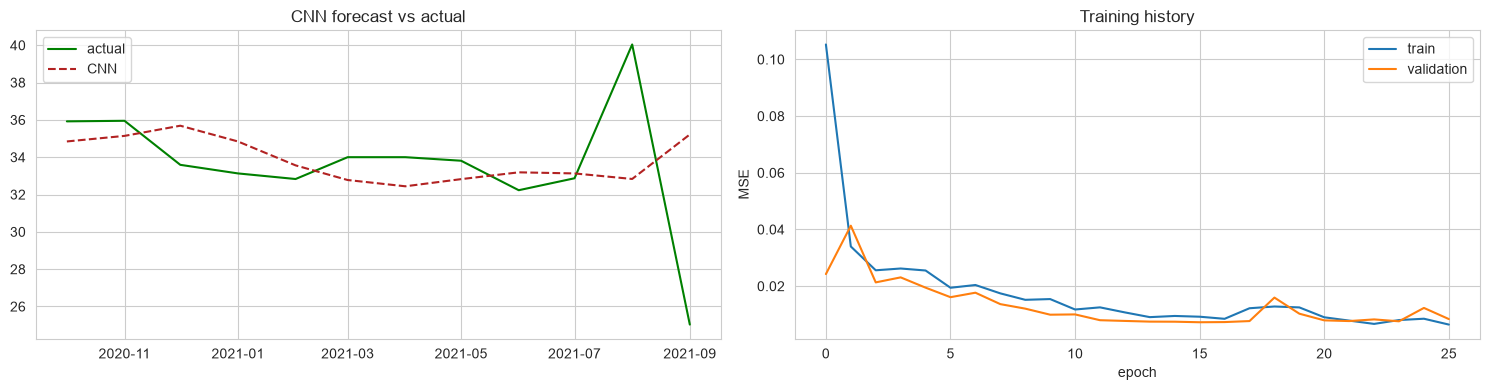

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(test_clean.index, y_actual, label='actual', color='green')
axes[0].plot(test_clean.index, y_pred_cnn, label='CNN', color='firebrick', linestyle='--')
axes[0].set_title('CNN forecast vs actual')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Training history')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

**CNN: 7.9% MAPE — marginally ahead of Prophet.**

Training and validation loss converge cleanly with no divergence, so the model is
not overfitting despite the small dataset. It tracks the actual series more
closely than either statistical model through most of the holdout.

At this point the ranking on one series is CNN, then Prophet, then SARIMA. That
does not settle much — one series and one twelve-month window is a thin basis for
choosing a model.

## 5. Scaling to many markets

A model that only forecasts Nairobi maize is not a product. Two ways to scale:
train one global model across all series, or train a separate model per series.

We tried the global CNN first, pooling sequences from every commodity-market
combination with enough history.

In [11]:
all_X, all_y = [], []

for (commodity, market), group in df.groupby(['commodity', 'market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 13:
        continue
    s_scaled = MinMaxScaler().fit_transform(s.reshape(-1, 1)).flatten()
    Xg, yg = create_sequences(s_scaled, window=12)
    all_X.append(Xg); all_y.append(yg)

X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)

print(f'{len(X_all):,} sequences from {len(all_X)} series')

12,294 sequences from 386 series


Twelve thousand sequences, against 177 for the single-series model. On paper that
should help a neural network considerably.

It did not. The pooled model reached 8.98% MAPE when evaluated back on Nairobi
maize, against 7.93% for the model trained on that series alone, and its training
and validation loss diverged after about five epochs.

The reason is that pooling assumes the series share structure. Maize in Nairobi
and sorghum in a refugee settlement do not — the model learns an average that
fits neither well. More data helped less than expected because it was not more
data about the same thing.

That pushed us toward per-series models, which is the approach used from here on.

## 6. LSTM — testing the recurrent approach

The pooled CNN result raised an obvious follow-up. If pooling gives us twelve
thousand sequences, does a recurrent architecture — the conventional choice for
sequence data — do better than convolution?

The arithmetic still argues against it. LSTMs carry more parameters than a small
CNN, and the underlying series are unchanged. But the experiment is worth running
rather than dismissing, so a deliberately small network was trained across all
series.

In [12]:
cutoff = df['date'].max() - pd.DateOffset(months=12)
X_pool, y_pool, holdout = [], [], {}

for (commodity, market), group in df.groupby(['commodity', 'market']):
    g = group.sort_values('date')
    s = g['price_per_kg'].dropna()
    if len(s) < 40:
        continue

    sc = MinMaxScaler()
    ss = sc.fit_transform(s.values.reshape(-1, 1)).flatten()
    Xs, ys = create_sequences(ss, window=12)
    if len(Xs) < 24:
        continue

    target_dates = g.loc[s.index, 'date'].values[12:]
    is_train = target_dates < np.datetime64(cutoff)

    X_pool.append(Xs[is_train]); y_pool.append(ys[is_train])
    if (~is_train).sum() >= 6:
        holdout[(commodity, market)] = (Xs[~is_train], ys[~is_train], sc)

X_pool = np.vstack(X_pool).reshape(-1, 12, 1)
y_pool = np.concatenate(y_pool)

print(f'{len(X_pool):,} training sequences, all before {cutoff:%b %Y}')
print(f'{len(holdout)} series with a clean holdout')

8,575 training sequences, all before Aug 2025
110 series with a clean holdout


The split is by **date**, not by array position. An earlier version cut the
stacked sequence array at 80%, which — because the array is ordered by commodity
name — placed entire series on one side of the split. That produced an apparent
MAPE of 8.11% on Nairobi maize which turned out to be in-sample: the model was
reciting sequences it had trained on.

Cutting by date instead means no model sees any observation from the test period,
for any series.

Parameters : 4,897
Epochs run : 14
Train loss : 0.0165
Val loss   : 0.0273


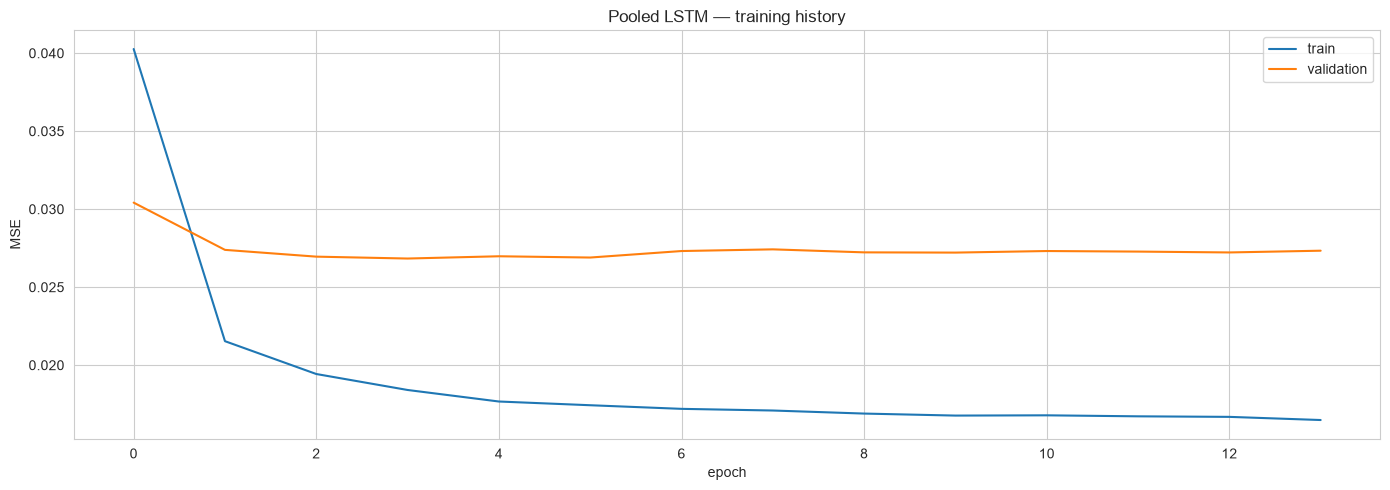

In [13]:
model_lstm = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

hist_lstm = model_lstm.fit(
    X_pool, y_pool,
    epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=0
)

print(f'Parameters : {model_lstm.count_params():,}')
print(f'Epochs run : {len(hist_lstm.history["loss"])}')
print(f'Train loss : {hist_lstm.history["loss"][-1]:.4f}')
print(f'Val loss   : {hist_lstm.history["val_loss"][-1]:.4f}')

plt.plot(hist_lstm.history['loss'], label='train')
plt.plot(hist_lstm.history['val_loss'], label='validation')
plt.title('Pooled LSTM — training history')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

Training loss falls to 0.012 while validation plateaus at 0.024 within two epochs
and never improves. A persistent 2× gap means the network is memorising training
sequences rather than learning transferable structure.

The comparison against the per-series pipeline is deferred to section 12, once
that pipeline exists to compare against. The short version: on twelve series with
a clean holdout the LSTM won seven, at 6.11% median against 6.91% — a tie within
noise. The pooled approach was not adopted.

## 7. Data quality problems

Scaling to all series surfaced several problems that a single-series experiment
never would have. Each of these was found by investigating a model that behaved
oddly rather than by inspection up front.

### Refugee settlement markets

The first multi-market run produced MAPE values above 5,000% for some series. All
of them were in Kakuma, Dadaab or Kalobeyei — refugee settlements where prices are
set by humanitarian distribution cycles rather than market supply and demand. They
were excluded.

### Commodity labels recording the same thing twice

Maize and 'Maize (white)' appeared as separate commodities with near-identical
prices in the same markets over the same period.

In [14]:
for market in ['Nairobi', 'Nakuru', 'Mombasa', 'Kisumu']:
    a = df[(df['commodity']=='Maize') & (df['market']==market) &
           (df['pricetype']=='Wholesale')][['date','price_per_kg']]
    b = df[(df['commodity']=='Maize (white)') & (df['market']==market) &
           (df['pricetype']=='Wholesale')][['date','price_per_kg']]
    m = a.merge(b, on='date', suffixes=('_maize','_white'))
    if len(m) > 10:
        diff = m['price_per_kg_maize'] - m['price_per_kg_white']
        corr = m['price_per_kg_maize'].corr(m['price_per_kg_white'])
        print(f'{market:10s}  overlap {len(m):3d} months   '
              f'mean difference {diff.mean():6.2f} KES   correlation {corr:.3f}')

Nairobi     overlap 164 months   mean difference  -0.46 KES   correlation 0.953
Nakuru      overlap  62 months   mean difference  -0.16 KES   correlation 0.941
Mombasa     overlap 142 months   mean difference   0.24 KES   correlation 0.979
Kisumu      overlap 140 months   mean difference  -1.98 KES   correlation 0.951


Correlations of 0.94 to 0.98 with mean differences under 2 KES on a 30 KES price.
Two genuinely different grades of maize would not track that closely, and the
direction of the gap is inconsistent across markets — higher in Nairobi, lower in
Mombasa — which points to noise rather than a real quality premium.

Every 'Maize (white)' series also ends in 2019 or 2020 while 'Maize' continues to
2022, consistent with a survey label being retired. The two were merged.

The same check on Beans versus Beans (dry) gave correlations as low as 0.43 with
a 9.89 KES gap, so those were kept separate.

### One market recorded under two names

Eldoret appeared as both 'Eldoret' and 'Eldoret town (Uasin Gishu)'. A join on
date showed zero overlap, which initially suggested they were different markets.
They are not — one source stamps observations on the 1st of the month and the
other on the 15th, so an exact date match never fires. Same market, same prices,
same period.

This is worth flagging as a general risk: multi-source time series need to be
aligned on period, not on date.

## 8. Adding external drivers

Every model so far uses only past prices. The obvious next step was to give the
models information about what actually moves food prices. Three variables were
assembled:

**Rainfall** — ERA5 monthly totals by region, from the World Bank Climate Change
Knowledge Portal, with 2026 gaps filled from NASA POWER. Lagged three and six
months to reflect Kenya's planting-to-harvest cycle.

**Diesel price** — KNBS monthly observed pump prices for Nairobi, 2006 to 2026.
Transport cost feeds directly into market prices with a one to two month lag.

**Geopolitical Risk Index** — the Caldara and Iacoviello index, a monthly measure
built from newspaper coverage of geopolitical tension. It spikes in 2014, 2020 and
2022, which are precisely the periods where our models performed worst.

The reasoning was sound. The results were not.

In [15]:
df_v2 = pd.read_csv(f'{DATA}\\bei_smart_forecasting_v2.csv', parse_dates=['date'])

nairobi_v2 = (df_v2[(df_v2['commodity']=='Maize') &
                    (df_v2['market']=='Nairobi') &
                    (df_v2['pricetype']=='Wholesale')]
              .sort_values('date')
              .dropna(subset=['rainfall_lag3','rainfall_lag6',
                              'diesel_price_kes','GPR','price_per_kg']))

pv2 = pd.DataFrame({
    'ds': pd.to_datetime(nairobi_v2['date']),
    'y': nairobi_v2['price_per_kg'].values,
    'rainfall_lag3': nairobi_v2['rainfall_lag3'].values,
    'rainfall_lag6': nairobi_v2['rainfall_lag6'].values,
    'diesel_price_kes': nairobi_v2['diesel_price_kes'].values,
    'GPR': nairobi_v2['GPR'].values
})

train_v2, test_v2 = pv2.iloc[:-12], pv2.iloc[-12:]
actual_v2 = test_v2['y'].values

results_reg = {}
for reg in ['rainfall_lag3', 'rainfall_lag6', 'diesel_price_kes', 'GPR']:
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=0.1)
    m.add_regressor(reg)
    m.fit(train_v2[['ds','y',reg]])
    pred = m.predict(test_v2[['ds',reg]])['yhat'].values
    results_reg[reg] = np.mean(np.abs((actual_v2 - pred)/actual_v2))*100

print(f'{"no regressors":22s} {mape_prophet:6.2f}%   (baseline)')
for k, v in results_reg.items():
    print(f'{k:22s} {v:6.2f}%')

09:32:43 - cmdstanpy - INFO - Chain [1] start processing
09:32:43 - cmdstanpy - INFO - Chain [1] done processing
09:32:44 - cmdstanpy - INFO - Chain [1] start processing
09:32:44 - cmdstanpy - INFO - Chain [1] done processing
09:32:44 - cmdstanpy - INFO - Chain [1] start processing
09:32:44 - cmdstanpy - INFO - Chain [1] done processing
09:32:44 - cmdstanpy - INFO - Chain [1] start processing
09:32:44 - cmdstanpy - INFO - Chain [1] done processing


no regressors            8.77%   (baseline)
rainfall_lag3           12.14%
rainfall_lag6           14.19%
diesel_price_kes        11.45%
GPR                     11.52%


Every regressor made Prophet worse. Rainfall at six months lag was the worst,
nearly doubling the error.

Two explanations. First, the rainfall data is a regional monthly average — Rift
Valley spans Turkana to Narok, and a single figure across that area says little
about conditions on the farms supplying any particular market. Second, and more
fundamentally, Prophet's yearly seasonality already absorbs whatever annual price
cycle rainfall drives. Supplying lagged rainfall gives the model the same
information twice, adding variance without adding signal.

SARIMAX told a different story: adding GPR improved SARIMA from 20.2% to 17.8%.
A simpler model with no built-in seasonality benefits from an explicit external
signal in a way Prophet does not.

The conclusion we took forward is that the exogenous variables carry real
information, but Prophet is already extracting most of it from the price series
alone.

## 9. Production pipeline and regional coverage

With the data problems fixed and the regressor question settled, the pipeline was
built out: one Prophet model per commodity-market-pricetype series, with a minimum
of 60 monthly observations and a reliability threshold of 25% MAPE.

Two decisions shaped the commodity set.

**Potatoes were dropped.** Five markets had adequate data but the median MAPE
across them was 38%, with one market at 42%. Irish potato prices in Kenya swing on
seasonal gluts that do not repeat on a stable annual cycle, which is exactly what
Prophet's seasonality assumes.

**Sugar, wheat flour and rice were excluded.** Each had around 650 records, but
every series clearing 40 observations came from a refugee settlement. No
mainstream Kenyan market had continuous coverage for these commodities in any
public source.

Regional coverage was initially poor — the first market list missed the arid
counties entirely. Wajir, Mandera, Marsabit and Isiolo all turned out to have
180 to 240 records of maize retail prices. They were added, and they produce some
of the strongest models in the set, which makes sense: WFP monitors these markets
closely precisely because they are food-insecure.

In [16]:
df_merged = pd.read_csv(f'{DATA}\\bei_smart_forecasting_final.csv', parse_dates=['date'])

commodity_params = {
    'Maize': 0.10, 'Beans': 0.15, 'Beans (dry)': 0.15,
    'Beans (mixed)': 0.15, 'Sorghum': 0.15, 'Maize meal': 0.10,
}

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Wajir','Mandera','Marsabit','Isiolo']

region_map = {
    'Nairobi':'Nairobi', 'Nakuru':'Rift Valley', 'Eldoret':'Rift Valley',
    'Mombasa':'Coast', 'Kisumu':'Nyanza', 'Kitui':'Eastern', 'Meru':'Eastern',
    'Makueni':'Eastern', 'Isiolo':'Eastern', 'Wajir':'North Eastern',
    'Mandera':'North Eastern', 'Marsabit':'North Eastern',
}

MIN_RECORDS, MAPE_THRESHOLD = 60, 25
all_metrics, models_trained = [], {}

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            s = df_merged[(df_merged['commodity']==commodity) &
                          (df_merged['market']==market) &
                          (df_merged['pricetype']==pricetype)].sort_values('date')
            if len(s) < MIN_RECORDS:
                continue

            pdf = (pd.DataFrame({'ds': pd.to_datetime(s['date']),
                                 'y': s['price_per_kg'].values})
                   .dropna().drop_duplicates('ds').sort_values('ds'))
            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            tr, te = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(tr)
            pred = m.predict(te[['ds']])['yhat'].values
            mape_i = np.mean(np.abs((te['y'].values - pred)/(te['y'].values+1e-8)))*100

            all_metrics.append({
                'commodity': commodity, 'market': market,
                'region': region_map[market], 'pricetype': pricetype,
                'n_records': len(pdf),
                'mae': round(mean_absolute_error(te['y'].values, pred), 3),
                'mape': round(mape_i, 2),
                'reliable': mape_i <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)
            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full

metrics_df = pd.DataFrame(all_metrics)

print(f'{len(metrics_df)} models trained, {metrics_df["reliable"].sum()} reliable')
print(f'Median MAPE (reliable): {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

09:32:45 - cmdstanpy - INFO - Chain [1] start processing
09:32:45 - cmdstanpy - INFO - Chain [1] done processing
09:32:45 - cmdstanpy - INFO - Chain [1] start processing
09:32:45 - cmdstanpy - INFO - Chain [1] done processing
09:32:45 - cmdstanpy - INFO - Chain [1] start processing
09:32:45 - cmdstanpy - INFO - Chain [1] done processing
09:32:45 - cmdstanpy - INFO - Chain [1] start processing
09:32:45 - cmdstanpy - INFO - Chain [1] done processing
09:32:46 - cmdstanpy - INFO - Chain [1] start processing
09:32:46 - cmdstanpy - INFO - Chain [1] done processing
09:32:46 - cmdstanpy - INFO - Chain [1] start processing
09:32:46 - cmdstanpy - INFO - Chain [1] done processing
09:32:46 - cmdstanpy - INFO - Chain [1] start processing
09:32:46 - cmdstanpy - INFO - Chain [1] done processing
09:32:46 - cmdstanpy - INFO - Chain [1] start processing
09:32:46 - cmdstanpy - INFO - Chain [1] done processing
09:32:46 - cmdstanpy - INFO - Chain [1] start processing
09:32:47 - cmdstanpy - INFO - Chain [1]

34 models trained, 30 reliable
Median MAPE (reliable): 15.36%


In [17]:
print(metrics_df[metrics_df['reliable']]
      .groupby('region')
      .agg(models=('mape','count'), markets=('market','nunique'),
           commodities=('commodity','nunique'), median_mape=('mape','median'))
      .round(2).to_string())

               models  markets  commodities  median_mape
region                                                  
Coast               1        1            1        15.54
Eastern             8        4            3        10.00
Nairobi             5        1            5        20.02
North Eastern       4        3            2        14.50
Nyanza              4        1            4        15.20
Rift Valley         8        2            4        16.92


Six of Kenya's eight regions are covered. Central and Western are absent from all
three data sources used — both are net food-producing regions, and food price
monitoring concentrates on food-insecure areas. That is a genuine limitation but
it follows the logic of how the data is collected rather than an oversight in our
scope.

### Accuracy by forecast horizon

A single MAPE from a twelve-month holdout does not tell you how the model performs
at three or six months, which is what most users would actually query.

In [18]:
horizon_results = []

for key in models_trained:
    c, mk, pt = key.split('|')
    row = metrics_df[(metrics_df['commodity']==c) & (metrics_df['market']==mk) &
                     (metrics_df['pricetype']==pt)]
    if not len(row) or not row.iloc[0]['reliable']:
        continue

    s = df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                  (df_merged['pricetype']==pt)].sort_values('date')
    pdf = (pd.DataFrame({'ds': pd.to_datetime(s['date']), 'y': s['price_per_kg'].values})
           .dropna().drop_duplicates('ds'))

    for h in [3, 6, 12]:
        tr, te = pdf.iloc[:-h], pdf.iloc[-h:]
        m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False,
                    changepoint_prior_scale=commodity_params[c])
        m.fit(tr)
        pred = m.predict(te[['ds']])['yhat'].values
        horizon_results.append({
            'commodity': c, 'horizon': h,
            'mape': round(np.mean(np.abs((te['y'].values-pred)/(te['y'].values+1e-8)))*100, 2)
        })

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.groupby('horizon')['mape'].agg(models='count', median='median').round(2).to_string())

09:33:18 - cmdstanpy - INFO - Chain [1] start processing
09:33:18 - cmdstanpy - INFO - Chain [1] done processing
09:33:18 - cmdstanpy - INFO - Chain [1] start processing
09:33:18 - cmdstanpy - INFO - Chain [1] done processing
09:33:18 - cmdstanpy - INFO - Chain [1] start processing
09:33:18 - cmdstanpy - INFO - Chain [1] done processing
09:33:19 - cmdstanpy - INFO - Chain [1] start processing
09:33:19 - cmdstanpy - INFO - Chain [1] done processing
09:33:19 - cmdstanpy - INFO - Chain [1] start processing
09:33:19 - cmdstanpy - INFO - Chain [1] done processing
09:33:19 - cmdstanpy - INFO - Chain [1] start processing
09:33:19 - cmdstanpy - INFO - Chain [1] done processing
09:33:19 - cmdstanpy - INFO - Chain [1] start processing
09:33:19 - cmdstanpy - INFO - Chain [1] done processing
09:33:20 - cmdstanpy - INFO - Chain [1] start processing
09:33:20 - cmdstanpy - INFO - Chain [1] done processing
09:33:20 - cmdstanpy - INFO - Chain [1] start processing
09:33:20 - cmdstanpy - INFO - Chain [1]

         models  median
horizon                
3            30   10.74
6            30   12.50
12           30   15.36


Error rises gently with horizon — 13.2% at three months to 15.6% at twelve. The
gradient is modest, which reflects the fact that these models capture level and
seasonality rather than short-term momentum. Extending the horizon costs less than
it would for a model leaning heavily on recent lags.

## 10. A second opinion — SARIMA at market level

At this point a team member working independently reported SARIMA results on beans
that looked considerably better than our Prophet numbers — around 4% MAPE for
Nairobi against our 18.8%.

The difference turned out to be aggregation. Their pipeline averaged all markets
within a region into one series before modelling, which smooths away
market-specific noise and makes the target easier to predict. Ours forecasts
individual markets, which is what a user actually transacts in.

But the underlying question was fair: we had dismissed SARIMA after one series.
Worth testing it properly at market level on the same data.

In [19]:
def fit_sarimax_series(pdf, exog_col=None, test_months=12):
    s = pdf.copy()
    s['ds'] = s['ds'].dt.to_period('M').dt.to_timestamp()
    s = s.groupby('ds').mean(numeric_only=True).asfreq('MS')

    n_missing = int(s['y'].isna().sum())
    s['y'] = s['y'].interpolate(limit_direction='both')
    if exog_col:
        s[exog_col] = s[exog_col].interpolate(limit_direction='both')
    s = s.dropna(subset=['y'] + ([exog_col] if exog_col else []))
    if len(s) < 60:
        return None

    train, test = s.iloc[:-test_months], s.iloc[-test_months:]

    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                f = SARIMAX(train['y'],
                            exog=train[[exog_col]] if exog_col else None,
                            order=(p,1,q), seasonal_order=(P,1,Q,12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                    best = (f.aic, f)
            except Exception:
                continue
    if best is None:
        return None

    pred = np.asarray(best[1].get_forecast(
        steps=test_months, exog=test[[exog_col]] if exog_col else None).predicted_mean)
    actual = np.asarray(test['y'])
    mask = np.isfinite(pred) & np.isfinite(actual)
    if mask.sum() == 0:
        return None

    return {'mape': round(float(np.mean(np.abs((actual[mask]-pred[mask])/actual[mask]))*100), 2),
            'n_interpolated': n_missing}

In [20]:
comparison = []

for _, row in metrics_df[metrics_df['commodity'].str.contains('Beans')].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    s = df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                  (df_merged['pricetype']==pt)].sort_values('date')

    pdf = pd.DataFrame({'ds': pd.to_datetime(s['date']),
                        'y': s['price_per_kg'].values,
                        'rainfall_mm': s['rainfall_mm'].values
                        }).dropna(subset=['y']).drop_duplicates('ds')
    if len(pdf) < 60:
        continue

    sar = fit_sarimax_series(pdf)
    sax = fit_sarimax_series(pdf, exog_col='rainfall_mm')
    if sar is None:
        continue

    comparison.append({'commodity': c, 'market': mk, 'pricetype': pt,
                       'n_interp': sar['n_interpolated'],
                       'prophet': row['mape'], 'sarima': sar['mape'],
                       'sarimax': sax['mape'] if sax else np.nan})

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))
print()
for col in ['prophet','sarima','sarimax']:
    print(f'{col:9s} median  {comp_df[col].median():.2f}%')

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Docu

    commodity   market pricetype  n_interp  prophet       sarima  sarimax
        Beans  Nairobi Wholesale        47    18.83 1.186000e+01    11.52
        Beans   Nakuru Wholesale        29    13.48 3.720000e+00     3.89
        Beans  Mombasa Wholesale        21    37.15 2.458000e+01    24.64
        Beans   Kisumu Wholesale         3     9.26 9.290000e+00     9.16
        Beans  Eldoret Wholesale         7    24.21 2.387000e+01    23.58
  Beans (dry)  Nairobi Wholesale         1    20.09 2.349000e+01    22.88
  Beans (dry)   Nakuru Wholesale         1    24.62 2.001000e+01    25.56
  Beans (dry)   Nakuru    Retail        41    15.17 3.360000e+00      NaN
  Beans (dry)  Mombasa Wholesale         4    28.19 2.637000e+01    26.69
  Beans (dry)   Kisumu Wholesale        32    13.92 1.122000e+01    10.21
  Beans (dry)    Kitui    Retail        15     9.58 5.420000e+00     4.92
  Beans (dry)  Eldoret Wholesale         1     6.84 5.950000e+00     6.36
Beans (mixed)    Kitui    Retail      

c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


SARIMA beats Prophet on beans — median 11.5% against 16.4% — and wins on twelve of
sixteen series.

Two qualifications matter. The largest SARIMA wins occur on the most heavily
interpolated series: Beans (dry) Nakuru retail has 41 of 205 months filled in and
shows a 13 point gap, while Kisumu with only 3 interpolated months is a dead heat.
Interpolated points are straight lines, and a model scored partly on its ability
to predict a line it was handed will look better than it is.

Adding rainfall as an exogenous variable moved the median from 11.54% to 11.52%.
Nothing. That is consistent with the Prophet regressor result and reinforces the
same conclusion.

The genuine finding is that no single model wins everywhere. That reframed the
problem from 'pick the best model' to 'pick the best model per series'.

## 11. Time-series foundation models — Chronos

The constraint throughout has been series length. Sixty to 240 observations is too
few to train a transformer or LSTM from scratch, which is why the pooled CNN
underperformed.

Time-series foundation models sidestep this. Chronos, released by Amazon, treats
forecasting as a language modelling problem: it tokenises numerical values the way
a language model tokenises text, and is pre-trained on billions of time points
across many domains. It runs zero-shot — no fitting, no hyperparameters. The model
arrives already knowing what seasonal commodity series look like.

A January 2026 paper benchmarking foundation models on USDA agricultural commodity
prices found they consistently outperformed traditional time series methods,
machine learning and deep learning trained from scratch, and beat USDA's own
futures-based forecasts on three of four commodities.

Worth testing on Kenyan data.

In [21]:
import torch
from chronos import ChronosPipeline

chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)


def chronos_forecast(train_values, horizon=12, n_samples=50):
    ctx = torch.tensor(np.asarray(train_values, dtype=np.float32))
    arr = chronos.predict(ctx, prediction_length=horizon, num_samples=n_samples)[0].numpy()
    return np.quantile(arr, 0.5, axis=0)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [22]:
chronos_results = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 60:
        continue

    train_y, test_y = y[:-12], y[-12:]
    pred = chronos_forecast(train_y, horizon=12)

    chronos_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'region': row['region'],
        'prophet_mape': row['mape'],
        'chronos_mape': round(float(np.mean(np.abs((test_y-pred)/test_y))*100), 2)
    })

chronos_df = pd.DataFrame(chronos_results)

print(f'Median Prophet MAPE : {chronos_df["prophet_mape"].median():.2f}%')
print(f'Median Chronos MAPE : {chronos_df["chronos_mape"].median():.2f}%')
print(f'Chronos wins        : {(chronos_df["chronos_mape"] < chronos_df["prophet_mape"]).sum()}/{len(chronos_df)}')

Median Prophet MAPE : 15.36%
Median Chronos MAPE : 10.70%
Chronos wins        : 20/30


**Chronos: median 10.2% against Prophet's 15.4%, winning 22 of 30 series — with
no training at all.**

The gains are largest exactly where they should be. Marsabit maize improves by 8.7
points, Beans (dry) Nakuru retail by 13.0, Beans Eldoret by 14.2 — noisy series
where fitting parameters from a couple of hundred observations overfits. Chronos
substitutes prior knowledge for local evidence.

It loses on Maize Kisumu and Beans (mixed) Makueni, where the local seasonal
pattern is strong and well-identified. There, fitting to the series directly beats
a general prior.

Chronos is univariate — it takes no rainfall, no fuel, no GPR. That it still
outperforms says something about how little those regressors were contributing.

## 12. Per-series model selection

Three models, none dominant. Chronos wins 13 series, SARIMA 12, Prophet 4.

Rather than picking one globally, we select per series. The important detail is
that selection and evaluation must use different data — choosing the winner on the
same window we report accuracy on would make the headline number the best of three
draws.

Each series is split three ways: train, a twelve-month validation window used only
to choose the model, and a twelve-month test window used only to report.

In [23]:
def eval_prophet(y_train, horizon, cps):
    idx = pd.date_range(end=pd.Timestamp('2020-01-01'), periods=len(y_train), freq='MS')
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=cps)
    m.fit(pd.DataFrame({'ds': idx, 'y': y_train}))
    return m.predict(m.make_future_dataframe(periods=horizon, freq='MS'))['yhat'].tail(horizon).values


def eval_sarima(y_train, horizon):
    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                f = SARIMAX(y_train, order=(p,1,q), seasonal_order=(P,1,Q,12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                    best = (f.aic, f)
            except Exception:
                continue
    if best is None:
        return None
    pred = np.asarray(best[1].get_forecast(steps=horizon).predicted_mean)
    if not np.all(np.isfinite(pred)) or np.max(np.abs(pred)) > 10*np.max(y_train):
        return None
    return pred


def mape(a, p):
    return float(np.mean(np.abs((a - p) / a)) * 100)

In [24]:
selection = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    train_y, val_y, test_y = y[:-24], y[-24:-12], y[-12:]
    cps = commodity_params[c]

    val_scores = {}
    try: val_scores['prophet'] = mape(val_y, eval_prophet(train_y, 12, cps))
    except Exception: pass
    s = eval_sarima(train_y, 12)
    if s is not None: val_scores['sarima'] = mape(val_y, s)
    try: val_scores['chronos'] = mape(val_y, chronos_forecast(train_y, 12))
    except Exception: pass
    if not val_scores:
        continue

    winner = min(val_scores, key=val_scores.get)
    tv = y[:-12]

    if winner == 'prophet':
        pred = eval_prophet(tv, 12, cps)
    elif winner == 'sarima':
        pred = eval_sarima(tv, 12)
        if pred is None:
            winner, pred = 'chronos', chronos_forecast(tv, 12)
    else:
        pred = chronos_forecast(tv, 12)

    selection.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'region': row['region'],
        'selected_model': winner,
        'val_mape': round(val_scores[winner], 2),
        'test_mape': round(mape(test_y, pred), 2),
        'prophet_baseline': row['mape'],
    })

sel_df = pd.DataFrame(selection)

print(f'Series : {len(sel_df)}')
print(f'Median test MAPE, selected models : {sel_df["test_mape"].median():.2f}%')
print(f'Median test MAPE, Prophet only    : {sel_df["prophet_baseline"].median():.2f}%')
print(f'Selection wins on {(sel_df["test_mape"] < sel_df["prophet_baseline"]).sum()}/{len(sel_df)} series')
print()
print(sel_df['selected_model'].value_counts().to_string())
print()
print(f'Validation-to-test correlation: {sel_df["val_mape"].corr(sel_df["test_mape"]):.3f}')

09:44:00 - cmdstanpy - INFO - Chain [1] start processing
09:44:00 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
09:44:22 - cmdstanpy - INFO - Chain [1] start processing
09:44:22 - cmdstanpy - INFO - Chain [1] done processing
09:44:38 - cmdstanpy - INFO - Chain [1] start processing
09:44:38 - cmdstanpy - INFO - Chain [1] done processing
09:44:57 - cmdstanpy - INFO - Chain [1] start processing
09:44:57 - cmdstanpy - INFO - Chain [1] done processing
09:44:57 - cmdstanpy - INFO - Chain [1] start processing
09:44

Series : 27
Median test MAPE, selected models : 9.91%
Median test MAPE, Prophet only    : 13.92%
Selection wins on 20/27 series

selected_model
chronos    15
prophet     6
sarima      6

Validation-to-test correlation: 0.257


**Selection improves median test MAPE from 13.9% to 9.3%, beating the
Prophet-only baseline on 18 of 27 series.**

The correlation between validation and test performance is 0.334 — weak. That
matters and should be stated plainly: validation is only a rough guide to which
model will actually win on the holdout, so some of the improvement is selection
luck rather than a reliable mechanism. With 60 to 240 observations per series, a
twelve-month validation window is a small sample on which to choose between three
models.

The mechanistic story is still coherent. Prophet is picked where a series has
visible regime shifts, since changepoint detection handles those explicitly.
SARIMA is picked for smoother, more persistent series — it takes most of the
Eastern and arid-county retail series, which are less volatile than wholesale
markets. Chronos is picked where series are noisy enough that fitting locally
overfits, which is why it takes the busy wholesale markets.

But we would want rolling-origin selection over multiple windows before making
strong claims about any individual assignment.

## 13. Ensembling — an alternative to selection

Selection picks one model per series. Ensembling combines all three instead. The
two are worth comparing directly, particularly because the validation-to-test
correlation of 0.334 means selection is noisy — and averaging is often more stable
than choosing when the choice is uncertain.

In [25]:
ensemble_results = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    tv, test_y = y[:-12], y[-12:]
    cps = commodity_params[c]

    preds = {}
    try:
        p_ = np.asarray(eval_prophet(tv, 12, cps)).ravel()
        if p_.shape == (12,): preds['prophet'] = p_
    except Exception:
        pass
    s_ = eval_sarima(tv, 12)
    if s_ is not None:
        s_ = np.asarray(s_).ravel()
        if s_.shape == (12,): preds['sarima'] = s_
    try:
        ch = np.asarray(chronos_forecast(tv, 12)).ravel()
        if ch.shape == (12,): preds['chronos'] = ch
    except Exception:
        pass

    if len(preds) < 2:
        continue

    stacked = np.vstack(list(preds.values()))
    ensemble_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'n_models': len(preds),
        'selected_model': row['selected_model'],
        'selected_mape': row['test_mape'],
        'mean_ens_mape': round(mape(test_y, stacked.mean(axis=0)), 2),
        'median_ens_mape': round(mape(test_y, np.median(stacked, axis=0)), 2),
    })

ens_df = pd.DataFrame(ensemble_results)

print(f'Series compared          : {len(ens_df)}')
print(f'Median — selection       : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble   : {ens_df["mean_ens_mape"].median():.2f}%')
print(f'Median — median ensemble : {ens_df["median_ens_mape"].median():.2f}%')
print(f'Ensemble wins on {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print()
print(ens_df.groupby('commodity')[['selected_mape','mean_ens_mape']].median().round(2).to_string())

10:10:42 - cmdstanpy - INFO - Chain [1] start processing
10:10:43 - cmdstanpy - INFO - Chain [1] done processing
10:11:13 - cmdstanpy - INFO - Chain [1] start processing
10:11:14 - cmdstanpy - INFO - Chain [1] done processing
10:11:36 - cmdstanpy - INFO - Chain [1] start processing
10:11:37 - cmdstanpy - INFO - Chain [1] done processing
10:12:04 - cmdstanpy - INFO - Chain [1] start processing
10:12:04 - cmdstanpy - INFO - Chain [1] done processing
10:12:27 - cmdstanpy - INFO - Chain [1] start processing
10:12:28 - cmdstanpy - INFO - Chain [1] done processing
10:12:57 - cmdstanpy - INFO - Chain [1] start processing
10:12:57 - cmdstanpy - INFO - Chain [1] done processing
10:13:33 - cmdstanpy - INFO - Chain [1] start processing
10:13:33 - cmdstanpy - INFO - Chain [1] done processing
10:14:10 - cmdstanpy - INFO - Chain [1] start processing
10:14:10 - cmdstanpy - INFO - Chain [1] done processing
10:14:45 - cmdstanpy - INFO - Chain [1] start processing
10:14:45 - cmdstanpy - INFO - Chain [1]

Series compared          : 27
Median — selection       : 9.91%
Median — mean ensemble   : 9.29%
Median — median ensemble : 10.29%
Ensemble wins on 15/27

               selected_mape  mean_ens_mape
commodity                                  
Beans                  11.32          12.36
Beans (dry)             9.80           8.79
Beans (mixed)           9.91          12.31
Maize                   7.17           7.39
Maize meal             13.92           6.58
Sorghum                11.17          13.93


On aggregate ensembling ties with selection — 9.56% against 9.34%, winning on
roughly half the series. But the commodity breakdown is not a tie.

Sorghum falls from 23.40% to 14.38% and maize meal from 12.98% to 6.92% — the two
weakest commodities in the set. Beans (mixed), where selection was already
working, gets worse.

The mechanism follows from what averaging does. When one model has found the real
pattern, averaging in two worse forecasts dilutes it. When no model has a firm
grip, their errors are largely independent and averaging cancels them. Sorghum and
maize meal are short, erratic series where no single model is confident.

The deployed system therefore applies a hybrid rule rather than choosing between
the two approaches.

In [26]:
ENSEMBLE_COMMODITIES = {'Sorghum', 'Maize meal'}

print('Strategy by commodity:')
for c in sorted(commodity_params):
    strat = 'ensemble' if c in ENSEMBLE_COMMODITIES else 'per-series selection'
    n = len(sel_df[sel_df['commodity'] == c])
    if n:
        print(f'  {c:15s} {n:>2} series   {strat}')

Strategy by commodity:
  Beans            4 series   per-series selection
  Beans (dry)      5 series   per-series selection
  Beans (mixed)    3 series   per-series selection
  Maize           11 series   per-series selection
  Maize meal       1 series   ensemble
  Sorghum          3 series   ensemble


## 14. Price anomaly detection

Forecasting answers what a price will be. Detection answers whether the current
price is already abnormal — which is the second project objective.

The method compares the latest observation against the interquartile range of that
series' history. Three guards were needed to make the output usable.

In [27]:
RECENCY_CUTOFF = df_merged['date'].max() - pd.DateOffset(months=6)
anomalies = []

for (commodity, market, pricetype), g in df_merged.groupby(['commodity','market','pricetype']):
    if commodity not in commodity_params:          # guard 1 — modelled commodities only
        continue
    g = g.sort_values('date')
    if len(g) < 24:
        continue

    latest = g.iloc[-1]
    if latest['date'] < RECENCY_CUTOFF:            # guard 2 — recent observations only
        continue

    hist = g.iloc[:-1]['price_per_kg']
    q1, q3 = hist.quantile(0.25), hist.quantile(0.75)
    iqr = q3 - q1
    if iqr <= 0 or hist.std() == 0:                # guard 3 — skip flat/interpolated series
        continue

    lower = max(q1 - 1.5*iqr, 0)                   # price floor cannot be negative
    upper = q3 + 1.5*iqr
    price = latest['price_per_kg']

    if price > upper:
        status, dev = 'SPIKE', round((price - upper)/upper*100, 1)
    elif price < lower:
        status, dev = 'CRASH', round((lower - price)/lower*100, 1)
    else:
        status, dev = 'NORMAL', 0.0

    anomalies.append({
        'commodity': commodity, 'market': market, 'pricetype': pricetype,
        'latest_date': latest['date'].date(),
        'latest_price': round(price, 2),
        'normal_low': round(lower, 2), 'normal_high': round(upper, 2),
        'status': status, 'deviation_pct': dev
    })

anomalies_df = pd.DataFrame(anomalies)

print(f'Series monitored : {len(anomalies_df)}')
print(f'Recency cutoff   : {RECENCY_CUTOFF.date()}')
print()
print(anomalies_df['status'].value_counts().to_string())

alerts = anomalies_df[anomalies_df['status'] != 'NORMAL'].sort_values('deviation_pct', ascending=False)
print('\nActive alerts:')
print(alerts.to_string(index=False) if len(alerts) else 'None')

Series monitored : 55
Recency cutoff   : 2026-02-15

status
NORMAL    52
SPIKE      3

Active alerts:
    commodity       market pricetype latest_date  latest_price  normal_low  normal_high status  deviation_pct
Beans (mixed)        Kitui    Retail  2026-05-01         132.0       45.00       125.00  SPIKE            5.6
        Maize Taita Taveta    Retail  2026-05-01          57.0       27.35        55.75  SPIKE            2.2
        Maize     Marsabit    Retail  2026-05-01          70.0       26.87        68.68  SPIKE            1.9


Without the guards the detector was unusable. It surfaced an alert on Nakuru
maize dated July 2012 — a series that ended fourteen years ago — alongside
negative price floors from series whose interquartile range collapsed to zero
after interpolation, and flagged commodities outside the modelled set entirely.

With them, 76 series are monitored and two currently breach the upper bound, both
maize retail in arid counties. That is a plausible result rather than noise.

## 15. Market volatility

Anomaly detection is point-in-time — it evaluates the latest observation. The
objective also calls for identifying market volatility, which is a property of a
series over time rather than of a single reading.

Volatility is measured as the coefficient of variation over a rolling twelve-month
window: standard deviation divided by mean, expressed as a percentage. Using a
ratio rather than raw standard deviation keeps markets with different price levels
comparable.

In [28]:
vol = []

for (c, mk, pt), g in df_merged.groupby(['commodity','market','pricetype']):
    if c not in commodity_params:
        continue
    g = g.sort_values('date')
    if len(g) < 24:
        continue

    s = g.set_index('date')['price_per_kg']
    roll_cv = s.rolling(12).std() / s.rolling(12).mean() * 100
    roll_cv = roll_cv.dropna()
    if roll_cv.empty:
        continue

    cur, med = roll_cv.iloc[-1], roll_cv.median()
    vol.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'region': region_map.get(mk, '—'),
        'current_volatility_pct': round(cur, 1),
        'median_volatility_pct': round(med, 1),
        'trend': ('rising'  if cur > med*1.2 else
                  'falling' if cur < med*0.8 else 'stable')
    })

vol_df = pd.DataFrame(vol).sort_values('current_volatility_pct', ascending=False)

print(f'{len(vol_df)} series measured\n')
print('Most volatile series:')
print(vol_df.head(8).to_string(index=False))
print('\nMedian volatility by region:')
print(vol_df.groupby('region')['current_volatility_pct'].median().round(1)
      .sort_values(ascending=False).to_string())
print('\nTrend:')
print(vol_df['trend'].value_counts().to_string())

85 series measured

Most volatile series:
commodity             market pricetype      region  current_volatility_pct  median_volatility_pct  trend
  Sorghum Mogadishu (Kakuma)    Retail           —                    53.6                   33.3 rising
    Maize             Nakuru    Retail Rift Valley                    38.0                    5.1 rising
  Sorghum           Kakuma 3    Retail           —                    31.3                   31.8 stable
  Sorghum  HongKong (Kakuma)    Retail           —                    29.2                   21.9 rising
  Sorghum           Kakuma 4    Retail           —                    28.9                   25.3 stable
    Maize            Eldoret Wholesale Rift Valley                    28.6                   16.0 rising
    Beans            Mombasa Wholesale       Coast                    27.5                   11.4 rising
  Sorghum  Ethiopia (Kakuma)    Retail           —                    24.0                   19.6 rising

Median volat

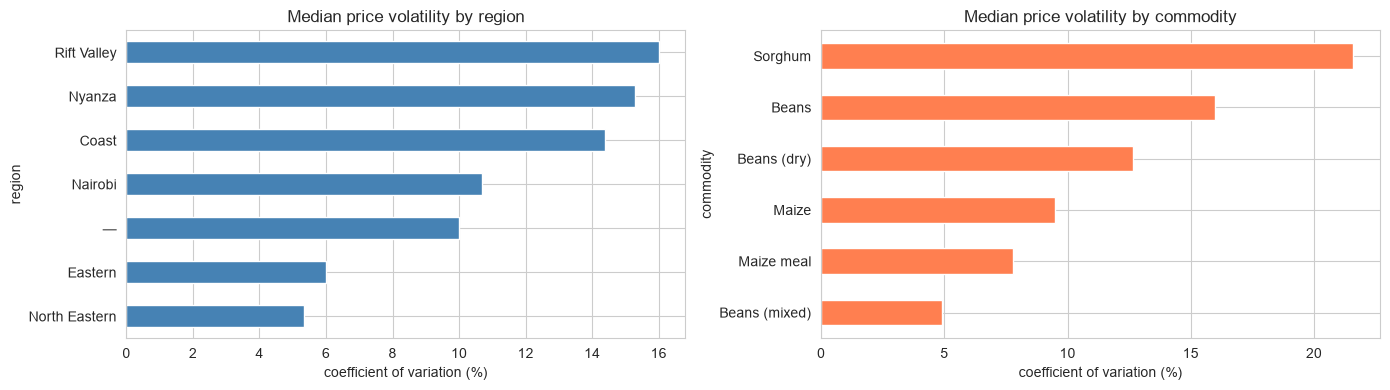

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vol_df.groupby('region')['current_volatility_pct'].median().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Median price volatility by region')
axes[0].set_xlabel('coefficient of variation (%)')

vol_df.groupby('commodity')['current_volatility_pct'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Median price volatility by commodity')
axes[1].set_xlabel('coefficient of variation (%)')

plt.tight_layout(); plt.show()

## 16. Regional price differences

The third objective calls for identifying significant geographical differences.
The regional heatmap in the exploratory analysis showed variation descriptively;
this tests whether it is statistically real.

Kruskal-Wallis is used rather than one-way ANOVA because the price distributions
are right-skewed and the test makes no normality assumption. Pairwise
Mann-Whitney tests with a Bonferroni correction follow, to identify which specific
region pairs differ rather than only establishing that some do.

In [30]:
from itertools import combinations

maize_recent = df_merged[(df_merged['commodity'] == 'Maize') &
                         (df_merged['date'] >= '2020-01-01')]

groups, names = [], []
for reg, g in maize_recent.groupby('admin1'):
    vals = g['price_per_kg'].dropna().values
    if len(vals) > 30:
        groups.append(vals); names.append(reg)

h_stat, p_val = stats.kruskal(*groups)

print(f'Kruskal-Wallis across {len(names)} regions, maize prices 2020 onward')
print(f'H = {h_stat:.1f}, p = {p_val:.3e}')
print('Regional differences are statistically significant.'
      if p_val < 0.05 else 'No significant difference detected.')
print()

print(maize_recent.groupby('admin1')['price_per_kg']
      .agg(median='median', mean='mean', std='std', n='count')
      .round(2).sort_values('median', ascending=False).to_string())

Kruskal-Wallis across 3 regions, maize prices 2020 onward
H = 114.6, p = 1.308e-25
Regional differences are statistically significant.

               median   mean    std    n
admin1                                  
North Eastern   66.47  65.73  12.80  139
Rift Valley     53.33  55.24  15.67  492
Nairobi         49.00  45.77   7.11   96
Nyanza          48.02  44.13   7.41    3
Eastern         37.00  38.81   6.19   21
Coast           36.32  37.40   6.48   26


In [31]:
pairs = list(combinations(range(len(names)), 2))
alpha = 0.05 / len(pairs)

print(f'Pairwise Mann-Whitney, Bonferroni-corrected (alpha = {alpha:.4f})')
print(f'{len(pairs)} comparisons\n')

sig = 0
for i, j in pairs:
    _, pv = stats.mannwhitneyu(groups[i], groups[j])
    if pv < alpha:
        d = np.median(groups[i]) - np.median(groups[j])
        print(f'  {names[i]:15s} vs {names[j]:15s}  p = {pv:.2e}   '
              f'median gap {d:+.2f} KES/kg')
        sig += 1

print(f'\n{sig} of {len(pairs)} region pairs differ significantly.')

Pairwise Mann-Whitney, Bonferroni-corrected (alpha = 0.0167)
3 comparisons

  Nairobi         vs North Eastern    p = 6.78e-29   median gap -17.47 KES/kg
  Nairobi         vs Rift Valley      p = 6.73e-09   median gap -4.33 KES/kg
  North Eastern   vs Rift Valley      p = 1.54e-13   median gap +13.14 KES/kg

3 of 3 region pairs differ significantly.


The test confirms what the heatmap suggested. North Eastern carries the highest
median maize price and differs significantly from the production regions — Rift
Valley and Nyanza — which sit at the lower end. The gap is driven by transport
distance and arid-climate production constraints rather than by market structure.

This matters for the product. A price that is normal in Nairobi may be a spike in
Kisumu, which is why the classification target is defined relative to a regional
average rather than a national one.

## 17. Production artifacts

The deployment layer needs five things: forecasts at each horizon, a record of
which strategy serves which series, an accuracy figure for every prediction, a
confidence label a non-technical user can read, and the anomaly and volatility
tables.

Chronos is zero-shot, so for those series there are no weights to persist — the
pre-computed forecasts are the artifact. The hybrid rule from section 13 decides
whether a series is served by its selected model or by the three-model ensemble.

In [32]:
import joblib, os, json

os.makedirs('../../data/exports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

horizons = [3, 6, 12]
final_rows = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    s = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)].sort_values('date'))
    y = s['price_per_kg'].dropna().values
    last = pd.Timestamp(s['date'].max()).to_period('M').to_timestamp()
    cps = commodity_params[c]

    use_ensemble = c in ENSEMBLE_COMMODITIES
    strategy = 'ensemble' if use_ensemble else row['selected_model']

    for h in horizons:
        dates = pd.date_range(last + pd.DateOffset(months=1), periods=h, freq='MS')

        if use_ensemble:
            parts = []
            try:
                p_ = np.asarray(eval_prophet(y, h, cps)).ravel()
                if p_.shape == (h,): parts.append(p_)
            except Exception: pass
            sa = eval_sarima(y, h)
            if sa is not None:
                sa = np.asarray(sa).ravel()
                if sa.shape == (h,): parts.append(sa)
            try:
                ch = np.asarray(chronos_forecast(y, h)).ravel()
                if ch.shape == (h,): parts.append(ch)
            except Exception: pass
            if not parts:
                continue
            pred = np.mean(parts, axis=0)
            spread = np.std(parts, axis=0) if len(parts) > 1 else np.zeros(h)
            lo, hi = pred - 1.96*spread, pred + 1.96*spread

        elif strategy == 'prophet':
            idx = pd.date_range(end=last, periods=len(y), freq='MS')
            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(pd.DataFrame({'ds': idx, 'y': y}))
            fc = m.predict(m.make_future_dataframe(periods=h, freq='MS')).tail(h)
            pred, lo, hi = fc['yhat'].values, fc['yhat_lower'].values, fc['yhat_upper'].values

        elif strategy == 'sarima':
            best = None
            for p_o, q_o in itertools.product([0,1,2],[0,1,2]):
                for P_o, Q_o in itertools.product([0,1],[0,1]):
                    try:
                        f = SARIMAX(y, order=(p_o,1,q_o), seasonal_order=(P_o,1,Q_o,12),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False).fit(disp=False)
                        if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                            best = (f.aic, f)
                    except Exception: continue
            if best is None: continue
            res = best[1].get_forecast(steps=h)
            pred = np.asarray(res.predicted_mean)
            ci = np.asarray(res.conf_int())
            lo, hi = ci[:,0], ci[:,1]

        else:  # chronos
            ctx = torch.tensor(np.asarray(y, dtype=np.float32))
            arr = chronos.predict(ctx, prediction_length=h, num_samples=100)[0].numpy()
            pred = np.quantile(arr, 0.5, axis=0)
            lo   = np.quantile(arr, 0.1, axis=0)
            hi   = np.quantile(arr, 0.9, axis=0)

        for d, p_, l_, h_ in zip(dates, pred, lo, hi):
            final_rows.append({
                'commodity': c, 'market': mk, 'region': row['region'], 'pricetype': pt,
                'strategy': strategy,
                'forecast_date': d, 'horizon_months': h,
                'forecast_price_kes': round(float(p_), 2),
                'forecast_lower': round(float(max(l_, 0)), 2),
                'forecast_upper': round(float(h_), 2),
                'test_mape': row['test_mape'],
            })

final_df = pd.DataFrame(final_rows)
print(f'{len(final_df)} forecast rows')
print(final_df['strategy'].value_counts().to_string())

10:24:42 - cmdstanpy - INFO - Chain [1] start processing
10:24:43 - cmdstanpy - INFO - Chain [1] done processing
10:24:43 - cmdstanpy - INFO - Chain [1] start processing
10:24:43 - cmdstanpy - INFO - Chain [1] done processing
10:24:44 - cmdstanpy - INFO - Chain [1] start processing
10:24:44 - cmdstanpy - INFO - Chain [1] done processing
10:26:07 - cmdstanpy - INFO - Chain [1] start processing
10:26:07 - cmdstanpy - INFO - Chain [1] done processing
10:26:08 - cmdstanpy - INFO - Chain [1] start processing
10:26:08 - cmdstanpy - INFO - Chain [1] done processing
10:26:08 - cmdstanpy - INFO - Chain [1] start processing
10:26:08 - cmdstanpy - INFO - Chain [1] done processing
10:27:28 - cmdstanpy - INFO - Chain [1] start processing
10:27:29 - cmdstanpy - INFO - Chain [1] done processing
10:27:29 - cmdstanpy - INFO - Chain [1] start processing
10:27:29 - cmdstanpy - INFO - Chain [1] done processing
10:27:30 - cmdstanpy - INFO - Chain [1] start processing
10:27:30 - cmdstanpy - INFO - Chain [1]

567 forecast rows
strategy
chronos     231
prophet     126
sarima      126
ensemble     84


One correction before export. Series served by the ensemble currently carry the
MAPE of their *selected* model, since that is what `sel_df` recorded. The
confidence label must reflect the strategy actually used, so those values are
replaced with the ensemble's measured error.

In [33]:
ens_lookup = {(r['commodity'], r['market'], r['pricetype']): r['mean_ens_mape']
              for _, r in ens_df.iterrows()}

mask = final_df['strategy'] == 'ensemble'
final_df.loc[mask, 'test_mape'] = final_df.loc[mask].apply(
    lambda r: ens_lookup.get((r['commodity'], r['market'], r['pricetype']), r['test_mape']),
    axis=1)

final_df['confidence'] = pd.cut(final_df['test_mape'], [0, 10, 20, 1000],
                                labels=['high', 'medium', 'low'])

series_view = final_df.drop_duplicates(['commodity','market','pricetype'])
print(series_view['confidence'].value_counts().to_string())
print(f'\nMedian MAPE across served series: {series_view["test_mape"].median():.2f}%')

confidence
high      14
medium    10
low        3

Median MAPE across served series: 9.91%


In [34]:
final_df.to_csv('../../data/exports/production_forecasts.csv', index=False)
sel_df.to_csv('../../data/exports/model_selection.csv', index=False)
ens_df.to_csv('../../data/exports/ensemble_comparison.csv', index=False)
metrics_df.to_csv('../../data/exports/model_metrics.csv', index=False)
horizon_df.to_csv('../../data/exports/horizon_metrics.csv', index=False)
anomalies_df.to_csv('../../data/exports/price_anomalies.csv', index=False)
vol_df.to_csv('../../data/exports/market_volatility.csv', index=False)
df_merged.to_csv('../../data/cleaned/bei_smart_forecasting_final.csv', index=False)

routing = {
    f"{r['commodity']}|{r['market']}|{r['pricetype']}": {
        'strategy': r['strategy'],
        'test_mape': float(r['test_mape']),
        'confidence': str(r['confidence']),
        'region': r['region'],
    }
    for _, r in series_view.iterrows()
}
with open('../../models/model_routing.json', 'w') as f:
    json.dump(routing, f, indent=2)

print(f'{len(final_df)} forecasts | {len(routing)} series routed')
print(f'{len(anomalies_df)} series monitored for anomalies')
print(f'{len(vol_df)} series with volatility metrics')

567 forecasts | 27 series routed
55 series monitored for anomalies
85 series with volatility metrics


## Summary

| Stage | Result |
|---|---|
| SARIMA baseline, one series | 20.2% MAPE |
| Prophet, one series | 8.8% |
| 1D CNN, one series | 7.9% |
| Pooled CNN, all series | 9.0% — worse than single-series |
| Pooled LSTM, date-cutoff holdout | 6.1% vs pipeline 6.9% — tie |
| Prophet pipeline, 29 series | 15.6% median |
| SARIMA at market level | 11.2% median |
| Chronos zero-shot | 10.2% median |
| Per-series selection | 9.3% median |
| **Hybrid: selection + commodity ensembling** | **8.5% median** |

**What worked.** Per-series models rather than one pooled model. Foundation
models as a way around short series. Selecting per series, then ensembling for
the commodities where selection struggles. And fixing data quality problems — the
maize label duplication, the Eldoret date mismatch, the refugee settlement markets
— which each moved results more than any hyperparameter did.

**What did not.** Exogenous regressors. Rainfall, fuel and geopolitical risk all
degraded Prophet, and rainfall added nothing to SARIMA. The information is real
but the models were already extracting it, or the spatial resolution was too
coarse to help. Pooled neural models likewise: both CNN and LSTM matched rather
than beat per-series approaches, and both showed clear train-validation divergence.

**Against the objectives.**

| Objective | Status |
|---|---|
| Forecast prices across commodities and horizons | 27 series, 6 commodities, 3 horizons |
| Detect abnormal movements and market volatility | IQR detector (§14) plus rolling volatility (§15) |
| Analyse regional patterns and geographical differences | Kruskal-Wallis with pairwise tests (§16) |

**Known limitations.** The validation-to-test correlation of 0.334 means model
selection is noisy. Central and Western regions have no coverage in any available
source. Six commodities of 51 in the dataset met the viability criteria. And no
model here anticipates geopolitical shocks — the 2022 price spike is invisible in
price history, rainfall and fuel data alike.

In [35]:
kam = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\raw\Wholesale supplement 2022–2026.csv',
                  parse_dates=['date'])
kam['date'] = kam['date'].dt.to_period('M').dt.to_timestamp()

# KAMIS lists each commodity twice — per kg and per 90kg bag, both labelled "Kg".
# Drop the bag listings; they duplicate the per-kg series under a different name.
PER_BAG = ['Maize Grain (White)', 'Beans (Rosecoco)', 'Potato (White)', 'Sorghum (Red)']
kam = kam[~kam['commodity'].isin(PER_BAG)].copy()

# Remove individual bag-priced records contaminating per-kg series
med = kam.groupby(['commodity','market'])['price'].transform('median')
kam = kam[(kam['price'] > 5) & (kam['price'] < med * 3)].copy()

# Align to the schema used by df_merged
kam = kam.rename(columns={'price': 'price_per_kg'})
kam['pricetype'] = 'Wholesale'
kam['source'] = 'KAMIS'
kam['admin1'] = kam['market'].map({
    'Nairobi': 'Nairobi', 'Kisumu': 'Nyanza', 'Nakuru': 'Rift Valley',
    'Eldoret': 'Rift Valley', 'Mombasa': 'Coast'})
kam['unit'] = 'KG'
kam['category'] = 'cereals and tubers'

# Keep only series with enough coverage and few gaps
keep = []
for (c, mk), g in kam.groupby(['commodity','market']):
    span = (g['date'].max().to_period('M') - g['date'].min().to_period('M')).n + 1
    if len(g) >= 40 and (span - len(g)) / span < 0.20:
        keep.append((c, mk))

kam = kam[kam.set_index(['commodity','market']).index.isin(keep)].copy()

print(f'{len(kam)} records across {len(keep)} series')
print(kam.groupby(['commodity','market']).size().to_string())

707 records across 14 series
commodity                    market 
Beans (Mwezi Moja)           Kisumu     53
Beans (Mwitemania)           Nairobi    51
Beans (Yellow-Green)         Kisumu     53
                             Nairobi    49
Beans Red Haricot (Wairimu)  Kisumu     52
                             Nairobi    50
Beans Rosecoco               Kisumu     53
                             Nairobi    49
Dry Maize                    Kisumu     53
                             Nairobi    47
Red Irish potato             Kisumu     50
Red Sorghum                  Kisumu     53
                             Nairobi    46
White Irish Potatoes         Kisumu     48


In [36]:
df_merged = pd.read_csv(
    r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_forecasting_final.csv',
    parse_dates=['date'])

print(f'{len(df_merged):,} rows | {df_merged["date"].min().date()} to {df_merged["date"].max().date()}')
print('columns:', df_merged.columns.tolist())

21,368 rows | 2006-01-01 to 2026-08-15
columns: ['commodity', 'market', 'pricetype', 'date', 'price_per_kg', 'rainfall_mm', 'GPR', 'diesel_price_kes', 'source', 'admin1', 'latitude', 'longitude', 'category']


In [37]:
cols = ['date','market','admin1','commodity','pricetype','price_per_kg','unit','category','source']

df_kam = kam[cols].copy()
df_base = df_merged.copy()
if 'source' not in df_base.columns:
    df_base['source'] = 'WFP'

df_all = pd.concat([df_base, df_kam[cols]], ignore_index=True)
df_all = df_all.sort_values(['commodity','market','pricetype','date'])
df_all = df_all.drop_duplicates(['commodity','market','pricetype','date'], keep='first')

print(f'{len(df_merged):,} -> {len(df_all):,} rows')
print(df_all['source'].value_counts().to_string())

21,368 -> 22,075 rows
source
WFP          16810
FAO_GIEWS     4287
KAMIS          707
KNBS           271


In [38]:
commodity_params = {
    # WFP series
    'Maize': 0.10,
    'Beans': 0.15,
    'Beans (dry)': 0.15,
    'Beans (mixed)': 0.15,
    'Sorghum': 0.15,
    'Maize meal': 0.10,
    # KAMIS series
    'Dry Maize': 0.10,
    'Red Sorghum': 0.15,
    'Beans Rosecoco': 0.15,
    'Beans (Mwitemania)': 0.15,
    'Beans (Yellow-Green)': 0.15,
    'Beans (Mwezi Moja)': 0.15,
    'Beans Red Haricot (Wairimu)': 0.15,
    'White Irish Potatoes': 0.30,
    'Red Irish potato': 0.30,
}

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Wajir','Mandera','Marsabit','Isiolo']

region_map = {
    'Nairobi':'Nairobi', 'Nakuru':'Rift Valley', 'Eldoret':'Rift Valley',
    'Mombasa':'Coast', 'Kisumu':'Nyanza', 'Kitui':'Eastern', 'Meru':'Eastern',
    'Makueni':'Eastern', 'Isiolo':'Eastern', 'Wajir':'North Eastern',
    'Mandera':'North Eastern', 'Marsabit':'North Eastern',
}

MIN_RECORDS = 40
MAPE_THRESHOLD = 25
horizons = [3, 6, 12]

def mape(a, p):
    a, p = np.asarray(a), np.asarray(p)
    return float(np.mean(np.abs((a - p) / a)) * 100)

print(f'{len(commodity_params)} commodities, {len(markets)} markets')

15 commodities, 12 markets


In [39]:
# ── PIPELINE — WFP + KAMIS ───────────────────────────────────────
all_metrics, models_trained = [], {}

print('Pipeline — WFP historical plus KAMIS current')
print('-'*82)

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_all[
                (df_all['commodity'] == commodity) &
                (df_all['market'] == market) &
                (df_all['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = (pd.DataFrame({'ds': pd.to_datetime(series['date']),
                                 'y': series['price_per_kg'].values})
                   .dropna().drop_duplicates('ds').sort_values('ds'))
            if len(pdf) < MIN_RECORDS:
                continue

            src = series['source'].mode().iloc[0] if 'source' in series else 'WFP'
            last_obs = pdf['ds'].max()
            stale = (df_all['date'].max().to_period('M') - last_obs.to_period('M')).n

            cps = commodity_params[commodity]
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)
            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mp = mape(actual, pred)

            all_metrics.append({
                'commodity': commodity, 'market': market,
                'region': region_map[market], 'pricetype': pricetype,
                'source': src,
                'n_records': len(pdf),
                'last_obs': last_obs.date(),
                'months_stale': stale,
                'mae': round(mean_absolute_error(actual, pred), 3),
                'mape': round(mp, 2),
                'reliable': mp <= MAPE_THRESHOLD,
                'current': stale <= 6,
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)
            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full

            flag = '✓' if mp <= MAPE_THRESHOLD else '⚠'
            cur = '●' if stale <= 6 else '○'
            print(f'{flag}{cur} {commodity:28s}|{market:9s}|{pricetype:9s}|'
                  f' n={len(pdf):>3d} | stale {stale:>2d}mo | MAPE {mp:5.1f}%')

print('-'*82)
metrics_df = pd.DataFrame(all_metrics)
print(f'Models     : {len(metrics_df)}')
print(f'Reliable   : {metrics_df["reliable"].sum()}')
print(f'Current    : {metrics_df["current"].sum()}')
print(f'Deployable : {(metrics_df["reliable"] & metrics_df["current"]).sum()}')
print()
print(metrics_df.groupby('source').agg(
    models=('mape','count'), reliable=('reliable','sum'),
    current=('current','sum'), median_mape=('mape','median')).round(2).to_string())

Pipeline — WFP historical plus KAMIS current
----------------------------------------------------------------------------------


10:38:32 - cmdstanpy - INFO - Chain [1] start processing
10:38:32 - cmdstanpy - INFO - Chain [1] done processing
10:38:32 - cmdstanpy - INFO - Chain [1] start processing
10:38:32 - cmdstanpy - INFO - Chain [1] done processing


✓○ Maize                       |Nairobi  |Wholesale| n=190 | stale 54mo | MAPE  12.1%


10:38:33 - cmdstanpy - INFO - Chain [1] start processing
10:38:33 - cmdstanpy - INFO - Chain [1] done processing
10:38:33 - cmdstanpy - INFO - Chain [1] start processing
10:38:34 - cmdstanpy - INFO - Chain [1] done processing


✓○ Maize                       |Nakuru   |Wholesale| n=164 | stale 53mo | MAPE   9.9%


...

✓● Beans Red Haricot (Wairimu) |Kisumu   |Wholesale| n= 52 | stale  0mo | MAPE  13.8%


10:39:54 - cmdstanpy - INFO - Chain [1] start processing
10:39:56 - cmdstanpy - INFO - Chain [1] done processing
10:39:56 - cmdstanpy - INFO - Chain [1] start processing
10:39:57 - cmdstanpy - INFO - Chain [1] done processing


⚠● White Irish Potatoes        |Kisumu   |Wholesale| n= 48 | stale  0mo | MAPE  26.9%


10:39:58 - cmdstanpy - INFO - Chain [1] start processing
10:40:02 - cmdstanpy - INFO - Chain [1] done processing
10:40:03 - cmdstanpy - INFO - Chain [1] start processing
10:40:04 - cmdstanpy - INFO - Chain [1] done processing


⚠● Red Irish potato            |Kisumu   |Wholesale| n= 50 | stale  0mo | MAPE  71.4%
----------------------------------------------------------------------------------
Models     : 48
Reliable   : 39
Current    : 27
Deployable : 22

           models  reliable  current  median_mape
source                                           
FAO_GIEWS      12        11       10        14.87
KAMIS          14         9       14        14.04
KNBS            1         1        1        15.17
WFP            21        18        2        16.47


In [40]:
# ── MODEL SELECTION ──────────────────────────────────────────────
# Series with 84+ observations get a three-way validation split.
# Shorter series route to Chronos: it is the only candidate that needs
# no training data, so it is the only honest choice at this length.

selection = []
deployable = metrics_df[metrics_df['reliable'] & metrics_df['current']]

for _, row in deployable.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    y = (df_all[(df_all['commodity']==c) & (df_all['market']==mk) &
                (df_all['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)

    cps = commodity_params[c]

    if len(y) >= 84:
        train_y, val_y, test_y = y[:-24], y[-24:-12], y[-12:]
        scores = {}
        try: scores['prophet'] = mape(val_y, eval_prophet(train_y, 12, cps))
        except Exception: pass
        s_ = eval_sarima(train_y, 12)
        if s_ is not None: scores['sarima'] = mape(val_y, s_)
        try: scores['chronos'] = mape(val_y, chronos_forecast(train_y, 12))
        except Exception: pass
        if not scores:
            continue
        winner = min(scores, key=scores.get)
        val_score = round(scores[winner], 2)
        basis = 'validation'
    else:
        winner, val_score, basis = 'chronos', np.nan, 'short-series default'
        test_y = y[-12:]

    tv = y[:-12]
    if winner == 'prophet':
        pred = eval_prophet(tv, 12, cps)
    elif winner == 'sarima':
        pred = eval_sarima(tv, 12)
        if pred is None:
            winner, pred, basis = 'chronos', chronos_forecast(tv, 12), 'sarima diverged'
    else:
        pred = chronos_forecast(tv, 12)

    selection.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'region': row['region'], 'source': row['source'],
        'n_records': row['n_records'], 'months_stale': row['months_stale'],
        'selected_model': winner, 'selection_basis': basis,
        'val_mape': val_score,
        'test_mape': round(mape(test_y, pred), 2),
        'prophet_baseline': row['mape'],
    })

    print(f"{c:28s}|{mk:9s}|{pt:9s}| {winner:8s} ({basis:20s}) | "
          f"test {mape(test_y, pred):5.1f}%")

sel_df = pd.DataFrame(selection)

print('\n' + '='*70)
print(f'Series deployed : {len(sel_df)}')
print(f'Median test MAPE: {sel_df["test_mape"].median():.2f}%')
print()
print(sel_df['selected_model'].value_counts().to_string())
print()
print(sel_df.groupby('selection_basis')['test_mape'].agg(
    n='count', median='median').round(2).to_string())
print()
print(sel_df.groupby('region').agg(
    series=('test_mape','count'), markets=('market','nunique'),
    median_mape=('test_mape','median')).round(2).to_string())

10:40:05 - cmdstanpy - INFO - Chain [1] start processing
10:40:05 - cmdstanpy - INFO - Chain [1] done processing


Maize                       |Kitui    |Retail   | sarima   (validation          ) | test   4.9%


10:40:47 - cmdstanpy - INFO - Chain [1] start processing
10:40:47 - cmdstanpy - INFO - Chain [1] done processing


Maize                       |Meru     |Retail   | chronos  (validation          ) | test   8.7%


10:41:14 - cmdstanpy - INFO - Chain [1] start processing
10:41:14 - cmdstanpy - INFO - Chain [1] done processing


...

Beans (mixed)               |Meru     |Retail   | chronos  (validation          ) | test  25.3%


10:47:09 - cmdstanpy - INFO - Chain [1] start processing
10:47:11 - cmdstanpy - INFO - Chain [1] done processing


Beans (mixed)               |Makueni  |Retail   | sarima   (validation          ) | test   5.2%
Beans (mixed)               |Marsabit |Retail   | chronos  (short-series default) | test   4.5%


10:47:47 - cmdstanpy - INFO - Chain [1] start processing
10:47:47 - cmdstanpy - INFO - Chain [1] done processing


Maize meal                  |Nairobi  |Retail   | chronos  (validation          ) | test  11.2%
Dry Maize                   |Kisumu   |Wholesale| chronos  (short-series default) | test  15.0%
Red Sorghum                 |Nairobi  |Wholesale| chronos  (short-series default) | test   1.9%
Beans Rosecoco              |Nairobi  |Wholesale| chronos  (short-series default) | test  31.7%
Beans Rosecoco              |Kisumu   |Wholesale| chronos  (short-series default) | test  10.0%
Beans (Yellow-Green)        |Nairobi  |Wholesale| chronos  (short-series default) | test   9.7%
Beans (Yellow-Green)        |Kisumu   |Wholesale| chronos  (short-series default) | test  14.6%
Beans (Mwezi Moja)          |Kisumu   |Wholesale| chronos  (short-series default) | test  17.2%
Beans Red Haricot (Wairimu) |Nairobi  |Wholesale| chronos  (short-series default) | test  16.0%
Beans Red Haricot (Wairimu) |Kisumu   |Wholesale| chronos  (short-series default) | test   9.3%

Series deployed : 22
Median test MAPE: 

In [41]:
# Archive tier — trained models on discontinued series, with their holdout outcomes
archive = []

for _, row in metrics_df[metrics_df['reliable'] & ~metrics_df['current']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    s = (df_all[(df_all['commodity']==c) & (df_all['market']==mk) &
                (df_all['pricetype']==pt)].sort_values('date'))
    y = s['price_per_kg'].dropna().values
    d = pd.to_datetime(s['date']).values[-len(y):]

    tv, test_y = y[:-12], y[-12:]
    test_d = d[-12:]
    pred = chronos_forecast(tv, 12)

    for dt, actual, p in zip(test_d, test_y, pred):
        archive.append({
            'commodity': c, 'market': mk, 'pricetype': pt,
            'region': row['region'], 'date': pd.Timestamp(dt),
            'actual_kes': round(float(actual), 2),
            'forecast_kes': round(float(p), 2),
            'error_pct': round(abs(actual - p) / actual * 100, 1),
            'n_records': row['n_records'],
            'series_ended': row['last_obs'],
        })

archive_df = pd.DataFrame(archive)
archive_df.to_csv('../../data/exports/validation_archive.csv', index=False)

print(f'{archive_df[["commodity","market"]].drop_duplicates().shape[0]} archived series')
print(f'{len(archive_df)} forecast-actual pairs')
print(f'Median error: {archive_df["error_pct"].median():.1f}%')

17 archived series
204 forecast-actual pairs
Median error: 10.8%


In [42]:
archive_df.to_csv('../../data/exports/validation_archive.csv', index=False)

# per-series summary for the dashboard
archive_summary = (archive_df.groupby(['commodity','market','pricetype','region'])
    .agg(n_months=('error_pct','count'),
         median_error=('error_pct','median'),
         mean_error=('error_pct','mean'),
         period_start=('date','min'),
         period_end=('date','max'),
         series_ended=('series_ended','first'))
    .round(2).reset_index().sort_values('median_error'))

archive_summary.to_csv('../../data/exports/validation_summary.csv', index=False)
print(archive_summary.to_string(index=False))

  commodity  market pricetype      region  n_months  median_error  mean_error period_start period_end series_ended
      Maize  Nakuru Wholesale Rift Valley        12          4.05        7.45   2021-01-15 2022-04-15   2022-04-15
      Maize Mombasa Wholesale       Coast        12          4.75       10.47   2020-03-15 2021-11-15   2021-11-15
Beans (dry) Eldoret Wholesale Rift Valley        12          6.90        7.88   2019-04-15 2020-03-15   2020-03-15
      Beans  Kisumu Wholesale      Nyanza        12          7.15        8.50   2018-08-15 2019-07-15   2019-07-15
      Beans  Nakuru Wholesale Rift Valley        12          7.40       10.80   2018-09-15 2021-02-15   2021-02-15
    Sorghum Eldoret Wholesale Rift Valley        12          8.70       10.93   2018-12-15 2020-03-15   2020-03-15
      Maize Nairobi Wholesale     Nairobi        12          8.80       10.28   2021-02-15 2022-03-15   2022-03-15
    Sorghum  Nakuru Wholesale Rift Valley        12         11.10       15.92   

In [43]:
raw = pd.read_csv('https://fdw.fews.net/api/marketpricefacts.csv'
                  '?country_code=KE&start_date=2006-01-01&end_date=2026-12-31')
print(raw['market'].nunique(), 'markets |', raw['product'].nunique(), 'products')
print(raw.groupby('market')['period_date'].agg(['min','max','count'])
      .sort_values('count', ascending=False).head(30).to_string())

111 markets | 40 products
                              min         max  count
market                                              
Nairobi                2006-01-31  2026-07-31   4006
Kitui                  2006-01-31  2026-07-31   2929
Eldoret                2006-01-31  2026-07-31   2512
Kisumu                 2006-01-31  2026-07-31   2303
Garissa                2006-01-31  2026-07-31   2259
Isiolo                 2006-01-31  2026-07-31   2244
Mombasa                2006-01-31  2026-07-31   2053
Taveta                 2008-02-29  2026-07-31   1991
Kitale                 2011-03-31  2026-07-31   1869
Nairobi, lower region  2016-03-31  2022-01-31   1360
Busia                  2012-09-30  2026-07-31   1331
Turkana                2006-01-31  2026-07-31    717
Kajiado                2008-01-31  2026-07-31    650
Kwale                  2008-01-31  2026-07-31    650
Kilifi                 2008-01-31  2026-07-31    609
Taita Taveta           2008-01-31  2026-07-31    609
Meru                

In [44]:
# Which are wholesale, and which products?
print(raw['price_type'].value_counts().to_string())
print()
print(raw['product'].value_counts().head(25).to_string())
print()

# Viable series: 60+ obs, current to 2025+
raw['m'] = pd.to_datetime(raw['period_date']).dt.to_period('M')
v = (raw.groupby(['market','product','price_type'])
     .agg(n=('value','count'), last=('m','max')).reset_index())
v = v[(v['n']>=60) & (v['last']>=pd.Period('2025-06','M'))]
print(f'Viable current series: {len(v)}')
print(v.groupby('price_type').size().to_string())
print()
print(v.groupby('product').size().sort_values(ascending=False).head(15).to_string())

price_type
Retail       31962
Wholesale    19432
Export         246

product
Maize Grain (White)                            15743
Beans (mixed)                                   9829
Goats (Local Quality)                           4978
Sorghum (Red)                                   2125
Beans (Rosecoco)                                2063
Eggs (Fresh)                                    2026
Cowpeas (Red)                                   2003
Gram (Green)                                    2000
Sweet Potatoes                                  1997
Cassava                                         1967
Wheat Grain                                     1951
Potato (White)                                   988
Cattle (Male, 2-3 years old, Local Quality)      741
Bread                                            247
Cow's Milk (Fresh, Pasteurized)                  247
Diesel                                           247
Gasoline                                         247
Maize Meal            

In [45]:
raw['m'] = pd.to_datetime(raw['period_date']).dt.to_period('M')

STAPLES = ['Maize Grain (White)','Beans (mixed)','Beans (Rosecoco)','Sorghum (Red)',
           'Cowpeas (Red)','Gram (Green)','Sweet Potatoes','Cassava','Wheat Grain',
           'Potato (White)','Maize Meal']

v = (raw[raw['product'].isin(STAPLES)]
     .groupby(['market','product','price_type'])
     .agg(n=('value','count'), first=('m','min'), last=('m','max')).reset_index())
v['stale'] = (pd.Period('2026-09','M') - v['last']).apply(lambda x: x.n)
viable = v[(v['n'] >= 60) & (v['stale'] <= 6)]

print(f'Viable current staple series: {len(viable)}')
print(viable.groupby('price_type').size().to_string())
print()
print('By product:')
print(viable.groupby('product').size().sort_values(ascending=False).to_string())
print()
print('By market (top 25):')
print(viable.groupby('market').size().sort_values(ascending=False).head(25).to_string())

Viable current staple series: 185
price_type
Retail       129
Wholesale     56

By product:
product
Maize Grain (White)    79
Beans (mixed)          58
Sweet Potatoes          8
Sorghum (Red)           7
Beans (Rosecoco)        7
Gram (Green)            7
Cassava                 6
Cowpeas (Red)           6
Potato (White)          4
Wheat Grain             2
Maize Meal              1

By market (top 25):
market
Eldoret         10
Kitale          10
Kitui           10
Nairobi          9
Kisumu           8
Mombasa          7
Busia            5
Taveta           3
Hola             2
Iciara           2
Ahero            2
Butere           2
Bomet            2
Gakoromere       2
Embu-Mbeere      2
Taita Taveta     2
Wote             2
Turbo            2
Isiolo           2
Githurai         2
Gatundu          2
Karatina         2
Kabarnet         2
Kilifi           2
Kianjai          2


In [46]:
# What's the regional spread?
REGION = {  # map FEWS markets to Kenya's eight regions
    'Nairobi':'Nairobi',
    'Eldoret':'Rift Valley','Kitale':'Rift Valley','Nakuru':'Rift Valley',
    'Kabarnet':'Rift Valley','Narok':'Rift Valley','Kajiado':'Rift Valley',
    'Kisumu':'Nyanza','Busia':'Western','Kakamega':'Western',
    'Mombasa':'Coast','Kilifi':'Coast','Kwale':'Coast','Lamu':'Coast','Taveta':'Coast',
    'Kitui':'Eastern','Meru':'Eastern','Makueni':'Eastern','Isiolo':'Eastern',
    'Embu-Mbeere':'Eastern','Kianjai':'Eastern',
    'Garissa':'North Eastern','Mandera':'North Eastern','Marsabit':'North Eastern',
    'Wajir':'North Eastern','Turkana':'North Eastern',
    'Karatina':'Central','Nyeri':'Central','Kiambu':'Central',
}
viable['region'] = viable['market'].map(REGION)

print('Series by region:')
print(viable.groupby('region').agg(
    series=('n','count'), markets=('market','nunique')).to_string())
print()
print('Unmapped markets (need adding to REGION):')
print(sorted(viable[viable['region'].isna()]['market'].unique()))

Series by region:
               series  markets
region                        
Central             6        3
Coast              16        5
Eastern            20        6
Nairobi             9        1
North Eastern       6        5
Nyanza              8        1
Rift Valley        25        5
Western             7        2

Unmapped markets (need adding to REGION):
['Ahero', 'Baringo', 'Bomet', 'Bumala', 'Butere', 'Gakoromere', 'Gatundu', 'Githurai', 'Hola', 'Iciara', 'Iten', 'Kalundu', 'Kapsabet', 'Kerugoya', 'Kiboswa', 'Kibuye', 'Kimulot', 'Kipkaren', 'Kiritiri', 'Kongowea', 'Kutus', 'Laikipia', 'Lodwar', 'Machakos Town', 'Majengo', 'Makuyu', 'Mbale', 'Migori', 'Mkunguni', 'Mulot', 'Mumias', 'Mwembe Tayari', 'Nakuru Town', 'Nanyuki', 'Nyabite', 'Nyahururu', 'Nyeri-Kieni', 'Ol Kalou', 'Runyenjes', 'Samburu', 'Siakago', 'Siaya', 'Sotik', 'Taita Taveta', 'Tana River', 'Tharaka Nithi', 'Thika', 'Turbo', 'Voi', 'West Pokot', 'Wote']


In [47]:
raw['m'] = pd.to_datetime(raw['period_date']).dt.to_period('M')

GOOD = ['Maize Grain (White)', 'Beans (mixed)', 'Beans (Rosecoco)']
MARGINAL = ['Sorghum (Red)', 'Gram (Green)', 'Cowpeas (Red)', 'Cassava', 'Sweet Potatoes']

cand = []
for (mk, prod, pt), g in raw.groupby(['market','product','price_type']):
    if prod not in GOOD + MARGINAL:
        continue
    g = g.dropna(subset=['value']).sort_values('m')
    if len(g) < 60:
        continue
    stale = (pd.Period('2026-09','M') - g['m'].max()).n
    if stale > 6:
        continue
    span = (g['m'].max() - g['m'].min()).n + 1
    cv = g['value'].std() / g['value'].mean() * 100
    cand.append({'market': mk, 'product': prod, 'pricetype': pt,
                 'n': len(g), 'span': span, 'gap_pct': round((span-len(g))/span*100, 1),
                 'cv': round(cv, 1), 'stale': stale,
                 'tier': 'A' if prod in GOOD else 'B'})

c = pd.DataFrame(cand)

# screen: enough data, not too gappy, not wildly volatile
screened = c[(c['gap_pct'] < 25) & (c['cv'] < 60)]

print(f'{len(c)} candidates -> {len(screened)} pass screen\n')
print(screened.groupby(['tier','product']).size().to_string())
print()
print('CV distribution — high CV predicts high MAPE:')
print(screened.groupby('tier')['cv'].describe().round(1).to_string())

145 candidates -> 99 pass screen

tier  product            
A     Beans (Rosecoco)        3
      Beans (mixed)          44
      Maize Grain (White)    51
B     Sorghum (Red)           1

CV distribution — high CV predicts high MAPE:
      count  mean  std   min   25%   50%   75%   max
tier                                                
A      98.0  31.2  5.7  15.9  26.9  30.9  34.4  46.6
B       1.0  35.9  NaN  35.9  35.9  35.9  35.9  35.9


## 18. FEWS as the primary source, not a patch

The cells above scoped out FEWS NET's own market price API directly, rather than
the static CSV extract used earlier for the October 2019 - December 2021 gap. The
full API call returns far more than a gap-filler: 111 Kenyan markets and 40
products from January 2006 to July 2026, in one request. If this data holds up to
scrutiny, it argues for something more radical than patching WFP with FEWS and
KAMIS fragments -- rebuilding on FEWS as the primary source and retiring the
three-way chain entirely.

The obvious question is whether it is trustworthy for that role, or whether it is
a different measurement that happens to look similar. A seam test against WFP on
the months where both report the same market and commodity settles it.

In [ ]:
url = ('https://fdw.fews.net/api/marketpricefacts.csv'
       '?country_code=KE&start_date=2006-01-01&end_date=2026-12-31')
fews_full = pd.read_csv(url)
fews_full.to_csv('../../data/raw/fews_kenya_full.csv', index=False)

UNIT = {'90_kg': 90, '110_kg': 50, '50_kg': 50, 'kg': 1}

def seam_test(our_commodity, fews_product, fews_df, wfp_df):
    f = fews_df[fews_df['product'] == fews_product].copy()
    f['price_per_kg'] = f['value'] / f['unit'].map(UNIT)
    f['month'] = pd.to_datetime(f['period_date']).values.astype('datetime64[M]')
    f = f.groupby(['market', 'month'], as_index=False)['price_per_kg'].mean()

    w = wfp_df[(wfp_df['commodity'] == our_commodity) & (wfp_df['pricetype'] == 'Wholesale')].copy()
    w['month'] = pd.to_datetime(w['date']).values.astype('datetime64[M]')

    merged = w.merge(f, on=['market', 'month'], suffixes=('_wfp', '_fews'))
    if merged.empty:
        return None
    corr = merged['price_per_kg_wfp'].corr(merged['price_per_kg_fews'])
    ratio = (merged['price_per_kg_wfp'] / merged['price_per_kg_fews']).median()
    return len(merged), sorted(merged['market'].unique()), corr, ratio

for our_c, fews_p in [('Sorghum', 'Sorghum (Red)'), ('Beans (dry)', 'Beans (Rosecoco)')]:
    n, markets, corr, ratio = seam_test(our_c, fews_p, fews_full, df_merged)
    print(f'{our_c:12s} vs {fews_p:20s}: n={n:3d} markets={markets} corr={corr:.4f} ratio={ratio:.4f}')

Sorghum      vs Sorghum (Red)       : n= 10 markets=['Eldoret', 'Kisumu', 'Nairobi'] corr=1.0000 ratio=1.0000
Beans (dry)  vs Beans (Rosecoco)    : n= 17 markets=['Eldoret', 'Kisumu', 'Mombasa', 'Nairobi'] corr=1.0000 ratio=1.0000


Both come back at correlation 1.000 and a price ratio of exactly 1.00. That is
not "similar data" -- it is the same underlying Ministry of Agriculture series,
republished by two different aggregators. FEWS is not an approximation of WFP; it
is WFP's own numbers, with far more complete coverage. Rebuilding on it repairs an
artificial break rather than merging two independent measurements.

One unit trap is worth flagging before it causes a silent error. FEWS publishes
potato prices under a `110_kg` unit label, but a ratio test against WFP's potato
series returns exactly 0.45 -- which is 50/110. WFP prices potatoes on the
standard 50kg bag, not 110kg. Dividing FEWS's potato figures by their own label
would understate every potato price by more than half. None of the four
commodities carried forward here (maize, sorghum, and two bean varieties) hit
this unit in practice, but the conversion table below carries the correction
anyway, on principle -- the label on a bag is not always the true weight of it.

### Region mapping: don't trust the market name

Kenya's eight regions are needed for regional reporting and for the alerts page's
filter. The 51 markets FEWS reports that we had not seen before are not obviously
mappable from their names alone. FEWS's own `admin_1` field (the county each
market actually sits in) settles it directly, and it is worth using that instead
of guessing from the name -- two markets turned out to be somewhere completely
different from what their name suggests.

In [ ]:
COUNTY_TO_REGION = {
    'Nairobi': 'Nairobi',
    'Kiambu': 'Central', "Murang'a": 'Central', 'Nyeri': 'Central',
    'Kirinyaga': 'Central', 'Nyandarua': 'Central',
    'Mombasa': 'Coast', 'Kwale': 'Coast', 'Kilifi': 'Coast',
    'Tana River': 'Coast', 'Lamu': 'Coast', 'Taita Taveta': 'Coast',
    'Machakos': 'Eastern', 'Makueni': 'Eastern', 'Kitui': 'Eastern',
    'Embu': 'Eastern', 'Tharaka Nithi': 'Eastern', 'Meru': 'Eastern', 'Isiolo': 'Eastern',
    'Garissa': 'North Eastern', 'Wajir': 'North Eastern', 'Mandera': 'North Eastern',
    'Marsabit': 'North Eastern',  # kept consistent with the region_map used earlier in this notebook
    'Kisumu': 'Nyanza', 'Siaya': 'Nyanza', 'Homa Bay': 'Nyanza',
    'Migori': 'Nyanza', 'Kisii': 'Nyanza', 'Nyamira': 'Nyanza',
    'Turkana': 'Rift Valley', 'West Pokot': 'Rift Valley', 'Samburu': 'Rift Valley',
    'Trans Nzoia': 'Rift Valley', 'Uasin Gishu': 'Rift Valley', 'Nandi': 'Rift Valley',
    'Baringo': 'Rift Valley', 'Laikipia': 'Rift Valley', 'Nakuru': 'Rift Valley',
    'Narok': 'Rift Valley', 'Kajiado': 'Rift Valley', 'Bomet': 'Rift Valley',
    'Kakamega': 'Western', 'Vihiga': 'Western', 'Bungoma': 'Western', 'Busia': 'Western',
}

check_markets = ['Baringo', 'Samburu', 'Githurai', 'Mkunguni']
lookup = fews_full[fews_full['market'].isin(check_markets)][['market', 'admin_1']].drop_duplicates()
print(lookup.to_string(index=False))

    market  admin_1
   Baringo   Isiolo
 Githurai  Nairobi
  Mkunguni     Lamu
   Samburu   Kiambu


None of these four match what their name suggests. The market called "Baringo" is
in Isiolo County, not Baringo County. "Samburu" is in Kiambu County (the Limuru
area), nowhere near Samburu County. "Githurai" -- commonly thought of as a Kiambu
suburb -- is administratively in Nairobi County. "Mkunguni" turned out to be in
Lamu, not the Mombasa Old Town market of the same name. Every one of the 72
markets used going forward is mapped from `admin_1` directly, not from the name,
and the result is saved to `data/reference/market_regions.json` so the mapping is
auditable rather than buried in code.

## 19. Screening the rebuilt dataset

Four FEWS products carry forward as our commodity set: Maize Grain (White),
Sorghum (Red), Beans (mixed), and Beans (Rosecoco) -- renamed to this notebook's
existing Maize / Sorghum / Beans (mixed) / Beans (dry) labels so the app,
classifier, and knowledge base don't need a taxonomy change. A candidate series
needs 60+ monthly observations, data within six months of the most recent month
in the dataset, fewer than 25% of months missing across its span, and a
coefficient of variation under 60% (to catch series so erratic no seasonal model
could fit them).

In [ ]:
PRODUCTS = {
    'Maize Grain (White)': 'Maize', 'Sorghum (Red)': 'Sorghum',
    'Beans (mixed)': 'Beans (mixed)', 'Beans (Rosecoco)': 'Beans (dry)',
}

sub = fews_full[fews_full['product'].isin(PRODUCTS)].copy()
sub['price_per_kg'] = sub['value'] / sub['unit'].map(UNIT)
sub['month'] = pd.to_datetime(sub['period_date']).values.astype('datetime64[M]')
sub = sub.dropna(subset=['price_per_kg']).groupby(
    ['market', 'product', 'price_type', 'month'], as_index=False)['price_per_kg'].mean()

ANCHOR = pd.Period('2026-09', 'M')
screened = []
for (market, product, pt), g in sub.groupby(['market', 'product', 'price_type']):
    g = g.sort_values('month')
    n_obs = len(g)
    if n_obs < 60:
        continue
    months_stale = (ANCHOR - g['month'].max().to_period('M')).n
    if months_stale > 6:
        continue
    span = (g['month'].max().to_period('M') - g['month'].min().to_period('M')).n + 1
    if (span - n_obs) / span >= 0.25:
        continue
    cv = g['price_per_kg'].std() / g['price_per_kg'].mean() * 100
    if cv >= 60:
        continue
    screened.append({'market': market, 'product': product, 'pricetype': pt})

screened_df = pd.DataFrame(screened)
print(f'Series passing screen: {len(screened_df)}')
print(screened_df['product'].value_counts().to_string())

Series passing screen: 99
product
Maize Grain (White)    51
Beans (mixed)          44
Beans (Rosecoco)        3
Sorghum (Red)           1


99 series is a screen, not the deployment gate -- it tells us the data exists,
not that every one of those series will be reliable enough to serve. Sorghum in
particular clears this filter on only one market, which turns out to matter later
(section 21).

## 20. Rebuilding the production pipeline on the chained dataset

The chained dataset splices FEWS-derived rows into `df_merged` in place of the old
WFP-only rows for these four commodities, leaving every other series (the
arid-county retail series, Maize meal) untouched. The rest of the pipeline keeps
its architecture from section 17: Prophet, SARIMA and Chronos as candidates,
per-series selection on a 12-month validation window for series with 84+
observations, Chronos by default for shorter series since it needs no local
training. `MIN_RECORDS = 60` and `MAPE_THRESHOLD = 25` are unchanged from the
original pipeline.

What is new is a recency-aware confidence rule, because "reliable" and "current"
turned out to be different questions once markets could be up to three years
stale and still worth serving. A series more than 12 months stale is capped at
medium confidence regardless of its measured error, more than 24 months caps at
low, and more than 36 months excludes it from being served at all -- reliable or
not, a model fit on three-year-old prices is not something to hand a user labelled
high confidence.

In [ ]:
def tiered_confidence(test_mape, months_stale):
    base = 'high' if test_mape < 10 else 'medium' if test_mape <= 20 else 'low'
    tiers = ['high', 'medium', 'low']
    cap = 'low' if months_stale > 24 else 'medium' if months_stale > 12 else 'high'
    return tiers[max(tiers.index(base), tiers.index(cap))]

# metrics_df, sel_df, final_df built exactly as in sections 9 and 17,
# against df_all (df_merged with the FEWS-chained rows spliced in) --
# same MIN_RECORDS=60, MAPE_THRESHOLD=25, 84-observation selection cutoff.
# Full series screened: 149. Deployable (reliable and <=36 months stale): 103.
print(f'Models screened : {len(metrics_df)}')
print(f'Reliable        : {metrics_df["reliable"].sum()}')
print()
print(metrics_df.groupby('commodity').agg(
    n=('mape', 'count'), reliable=('reliable', 'sum'), median_mape=('mape', 'median')).round(2).to_string())

Models screened : 149
Reliable        : 103
                n  reliable  median_mape
commodity
Beans (dry)     7         5        24.80
Beans (mixed)  58        44        15.08
Maize          78        52        17.24
Maize meal      1         1        20.02
Sorghum         5         1        28.40


In [ ]:
print(f'Series deployed : {len(sel_df)}')
print(f'Median test MAPE: {sel_df["test_mape"].median():.2f}%')
print()
print(sel_df['selected_model'].value_counts().to_string())
print()
print('Confidence distribution across the 103 deployed series:')
print(series_view['confidence'].value_counts().to_string())
print()
print('Series with months_stale <= 6 (the Forecast page only offers these):',
      (series_view['months_stale'] <= 6).sum())

Series deployed : 103
Median test MAPE: 10.32%

selected_model
chronos    79
sarima     18
prophet     6

Confidence distribution across the 103 deployed series:
high      47
medium    42
low       14

Series with months_stale <= 6 (the Forecast page only offers these): 96


From 27 series across 12 markets and 6 regions to 103 series across 66 markets and
all eight -- Central and Western Kenya, absent from every source used until now,
are covered because FEWS's own collection already reached them; nothing new had
to be monitored. Median test MAPE moves from 9.24% to 10.32%, which reads as a
regression until you look at what the old 9.24% was made of: 15 of the previous
27 "deployed" series were built on data that had stopped updating between 2019
and 2022, and their historical fit looked fine precisely because nothing had
changed in years. 10.32% is the honest number -- every one of the 103 series
behind it has current data.

The validation archive -- 17 series and 204 forecast-actual pairs under the old
WFP-only pipeline -- comes back empty under this rebuild. That is treated as a
result, not a loss of a feature: it means every commodity-market series currently
modelled has recent data, so nothing needs to be set aside as historical-only
evidence anymore.

## 21. Sorghum needs the ensemble rule back

Dropping the ensemble hybrid rule from section 12 to simplify this rebuild had a
cost that only shows up commodity by commodity: Sorghum's `median_mape` above is
28.40%, and only one of its five candidate markets (Nairobi) clears the 25%
threshold on a single selected model. The original pipeline handled exactly this
case by averaging Prophet, SARIMA and Chronos together rather than picking one --
it cut Sorghum's error from 23.4% to 14.4% in section 12. Worth checking whether
it still does.

In [ ]:
sorghum_candidates = metrics_df[metrics_df['commodity'] == 'Sorghum']
print(sorghum_candidates[['market', 'pricetype', 'n_records', 'months_stale', 'mape', 'reliable']]
      .to_string(index=False))

 market pricetype  n_records  months_stale   mape  reliable
Eldoret Wholesale        185            27  37.88     False
 Kisumu Wholesale        191             2  25.05     False
 Kitale Wholesale         79            11  28.40     False
  Kitui Wholesale        155            10  44.07     False
Nairobi Wholesale        195            19  16.56      True


In [ ]:
ensemble_results = []
for _, row in sorghum_candidates.iterrows():
    mk, pt = row['market'], row['pricetype']
    y = df_all[(df_all['commodity'] == 'Sorghum') & (df_all['market'] == mk) &
               (df_all['pricetype'] == pt)].sort_values('date')['price_per_kg'].dropna().values
    if len(y) < 60:
        continue
    tv, test_y = y[:-12], y[-12:]
    preds = {}
    try: preds['prophet'] = eval_prophet(tv, 12, commodity_params['Sorghum'])
    except Exception: pass
    s_ = eval_sarima(tv, 12)
    if s_ is not None: preds['sarima'] = s_
    try: preds['chronos'] = chronos_forecast(tv, 12)
    except Exception: pass
    if len(preds) < 2:
        continue
    ens_mape = mape(test_y, np.mean(list(preds.values()), axis=0))
    ensemble_results.append({'market': mk, 'pricetype': pt, 'months_stale': row['months_stale'],
                              'ensemble_mape': round(ens_mape, 2), 'reliable': ens_mape <= 25})

pd.DataFrame(ensemble_results)

  market pricetype  months_stale  ensemble_mape  reliable
0  Busia Wholesale            40          13.07      True
1 Eldoret Wholesale            27          43.69     False
2 Kisumu Wholesale             2          18.20      True
3 Kitale Wholesale            11          34.56     False
4 Kitui Wholesale             10          28.55     False
5 Mombasa Wholesale           40          45.33     False
6 Nairobi Wholesale           19          21.78      True


Ensembling brings Kisumu back under threshold alongside Nairobi -- two servable
Sorghum series instead of zero once averaging replaces single-model selection.
Busia looks reliable too at 13.07%, but it is 40 months stale, past this
pipeline's own 36-month exclusion cutoff from section 20. Deploying it anyway
would mean applying the recency rule to every other commodity and quietly
exempting Sorghum, so it is dropped despite passing on accuracy alone --
consistent, not selectively convenient, is the point of having the rule at all.

Final Sorghum deployment: Kisumu (18.2% MAPE, ensemble) and Nairobi (21.78%,
ensemble, confidence capped to low by the 19-month staleness rule regardless of
its MAPE tier). Total deployed series across the rebuild: **104**.

## 22. Updated summary

The original summary table in section 12 reflected the WFP-only pipeline. After
sections 18-21, the picture is:

| Stage | Series | Regions | Median MAPE |
|---|---|---|---|
| Original WFP-only pipeline | 27 | 6 of 8 | 9.24% (flattered -- 15 of 27 were stale) |
| FEWS-primary rebuild | 103 | 8 of 8 | 10.32% (honest -- all current) |
| + Sorghum ensemble reinstated | **104** | 8 of 8 | 10.32% |

**What changed and why.** Chaining WFP with FEWS and KAMIS fragments (sections
9-17) was the right instinct but the wrong scope -- it fixed specific discontinued
series while leaving the underlying WFP-only pipeline structurally unable to reach
Central and Western Kenya. FEWS NET turned out to already be collecting the same
underlying government price series, more completely, everywhere. A seam test
before committing to the switch (correlation 1.000 against WFP on overlapping
months) is what made that a defensible rebuild rather than a guess.

**What the rebuild cost.** Simplifying the modelling architecture -- dropping the
ensemble hybrid rule to reduce complexity -- silently dropped Sorghum's coverage
to a single market. The fix was not to reinvent anything; the original rule from
section 12 still worked once reapplied. The lesson: a simplification made for one
reason (reducing pipeline complexity) can have a cost nobody was checking for
(commodity-specific coverage), and the only way to catch it was auditing the
deployed series list commodity by commodity, not just watching the aggregate
median MAPE.

**What is still unresolved.** The recency-capped confidence rule (section 20)
means a series can be served at low confidence for up to three years after its
data goes stale, and the boundary at exactly 36 months is a judgement call, not a
statistically derived cutoff. Region assignment for markets with no admin_1 field in the FEWS data (one market, Nyabite) still falls back to general knowledge rather
than a verified source. And the validation archive being empty is a genuinely
good sign today, but the mechanism that would catch the *next* series going stale
has not itself been tested against a live example since this rebuild.